# fetch_prom_stats

Первичный запрос данных из Prometheus и первичный EDA.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['figure.dpi'] = 300

In [2]:
from src.data_loader import fetch_frame
# df = fetch_frame()
df = fetch_frame(
    start_date="2024-11-25 18:00:00",
    end_date  ="2024-12-11 12:10:00",
    use_cache=True,             # всегда тянуть свежие данные
    cache_filename="multivar_9001_20241125_20241211.parquet",
    # verbose=True                 # чтобы видеть прогресс
)
df.rename(columns={'common_cad_avg1h_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'common_cad_avg1h'}, inplace=True)
df.rename(columns={'db_insert_cad_avg1h_instance_10.201.92.176:8010_job_consumer_ml_to_db_service_castle': 'db_insert_cad_avg1h'}, inplace=True)
df.rename(columns={'kafka_network_cad_avg1h_instance_10.201.92.176:8010_job_consumer_ml_to_db_service_castle': 'kafka_network_cad_avg1h'}, inplace=True)
df.rename(columns={'counter_events_total_instance_consumer_from_ws_with_metrics:8000_job_consumer_from_ws_with_metrics_service_castle': 'counter_events_total'}, inplace=True)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())


/Users/nikolayborovets/Desktop/bachelor_diploma/realtime_anomaly_analytics/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                     common_cad_avg1h  db_insert_cad_avg1h  \
ts                                                           
2024-11-25 18:00:30               NaN             3.053300   
2024-11-25 18:00:45               NaN             3.053300   
2024-11-25 18:01:00        570.036987             3.053300   
2024-11-25 18:01:15        570.036987             3.053300   
2024-11-25 18:01:30        570.036987             3.013525   

                     kafka_network_cad_avg1h  counter_events_total  
ts                                                                  
2024-11-25 18:00:30                420.23265                   NaN  
2024-11-25 18:00:45                420.23265                   NaN  
2024-11-25 18:01:00                420.23265            10639901.0  
2024-11-25 18:01:15                420.23265            10639901.0  
2024-11-25 18:01:30                390.79950            10639901.0  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90759 entries, 2024-11-25 18:

In [3]:
df.info()
df.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90759 entries, 2024-11-25 18:00:30 to 2024-12-11 12:10:00
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   common_cad_avg1h         90757 non-null  float64
 1   db_insert_cad_avg1h      90571 non-null  float64
 2   kafka_network_cad_avg1h  90571 non-null  float64
 3   counter_events_total     90543 non-null  float64
dtypes: float64(4)
memory usage: 3.5 MB


In [4]:
df


,common_cad_avg1h,db_insert_cad_avg1h,kafka_network_cad_avg1h,counter_events_total
ts,,,,
2024-11-25 18:01:00,570.036987,3.053300,420.232650,10639901.0
2024-11-25 18:01:15,570.036987,3.053300,420.232650,10639901.0
2024-11-25 18:01:30,570.036987,3.013525,390.799500,10639901.0
2024-11-25 18:01:45,570.036987,3.013525,390.799500,10639901.0
2024-11-25 18:02:00,777.154144,3.013525,390.799500,10641497.0
...,...,...,...,...
2024-12-11 11:15:30,340.807742,6.504314,255.680136,13832366.0
2024-12-11 11:15:45,340.807742,6.504314,255.680136,13832366.0
2024-12-11 11:16:00,341.589371,6.504314,255.680136,13832366.0


In [5]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

                     common_cad_avg1h  db_insert_cad_avg1h  \
ts                                                           
2024-11-25 18:01:00        570.036987             3.053300   
2024-11-25 18:01:15        570.036987             3.053300   
2024-11-25 18:01:30        570.036987             3.013525   
2024-11-25 18:01:45        570.036987             3.013525   
2024-11-25 18:02:00        777.154144             3.013525   

                     kafka_network_cad_avg1h  counter_events_total  
ts                                                                  
2024-11-25 18:01:00                420.23265            10639901.0  
2024-11-25 18:01:15                420.23265            10639901.0  
2024-11-25 18:01:30                390.79950            10639901.0  
2024-11-25 18:01:45                390.79950            10639901.0  
2024-11-25 18:02:00                390.79950            10641497.0  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90543 entries, 2024-11-25 18:

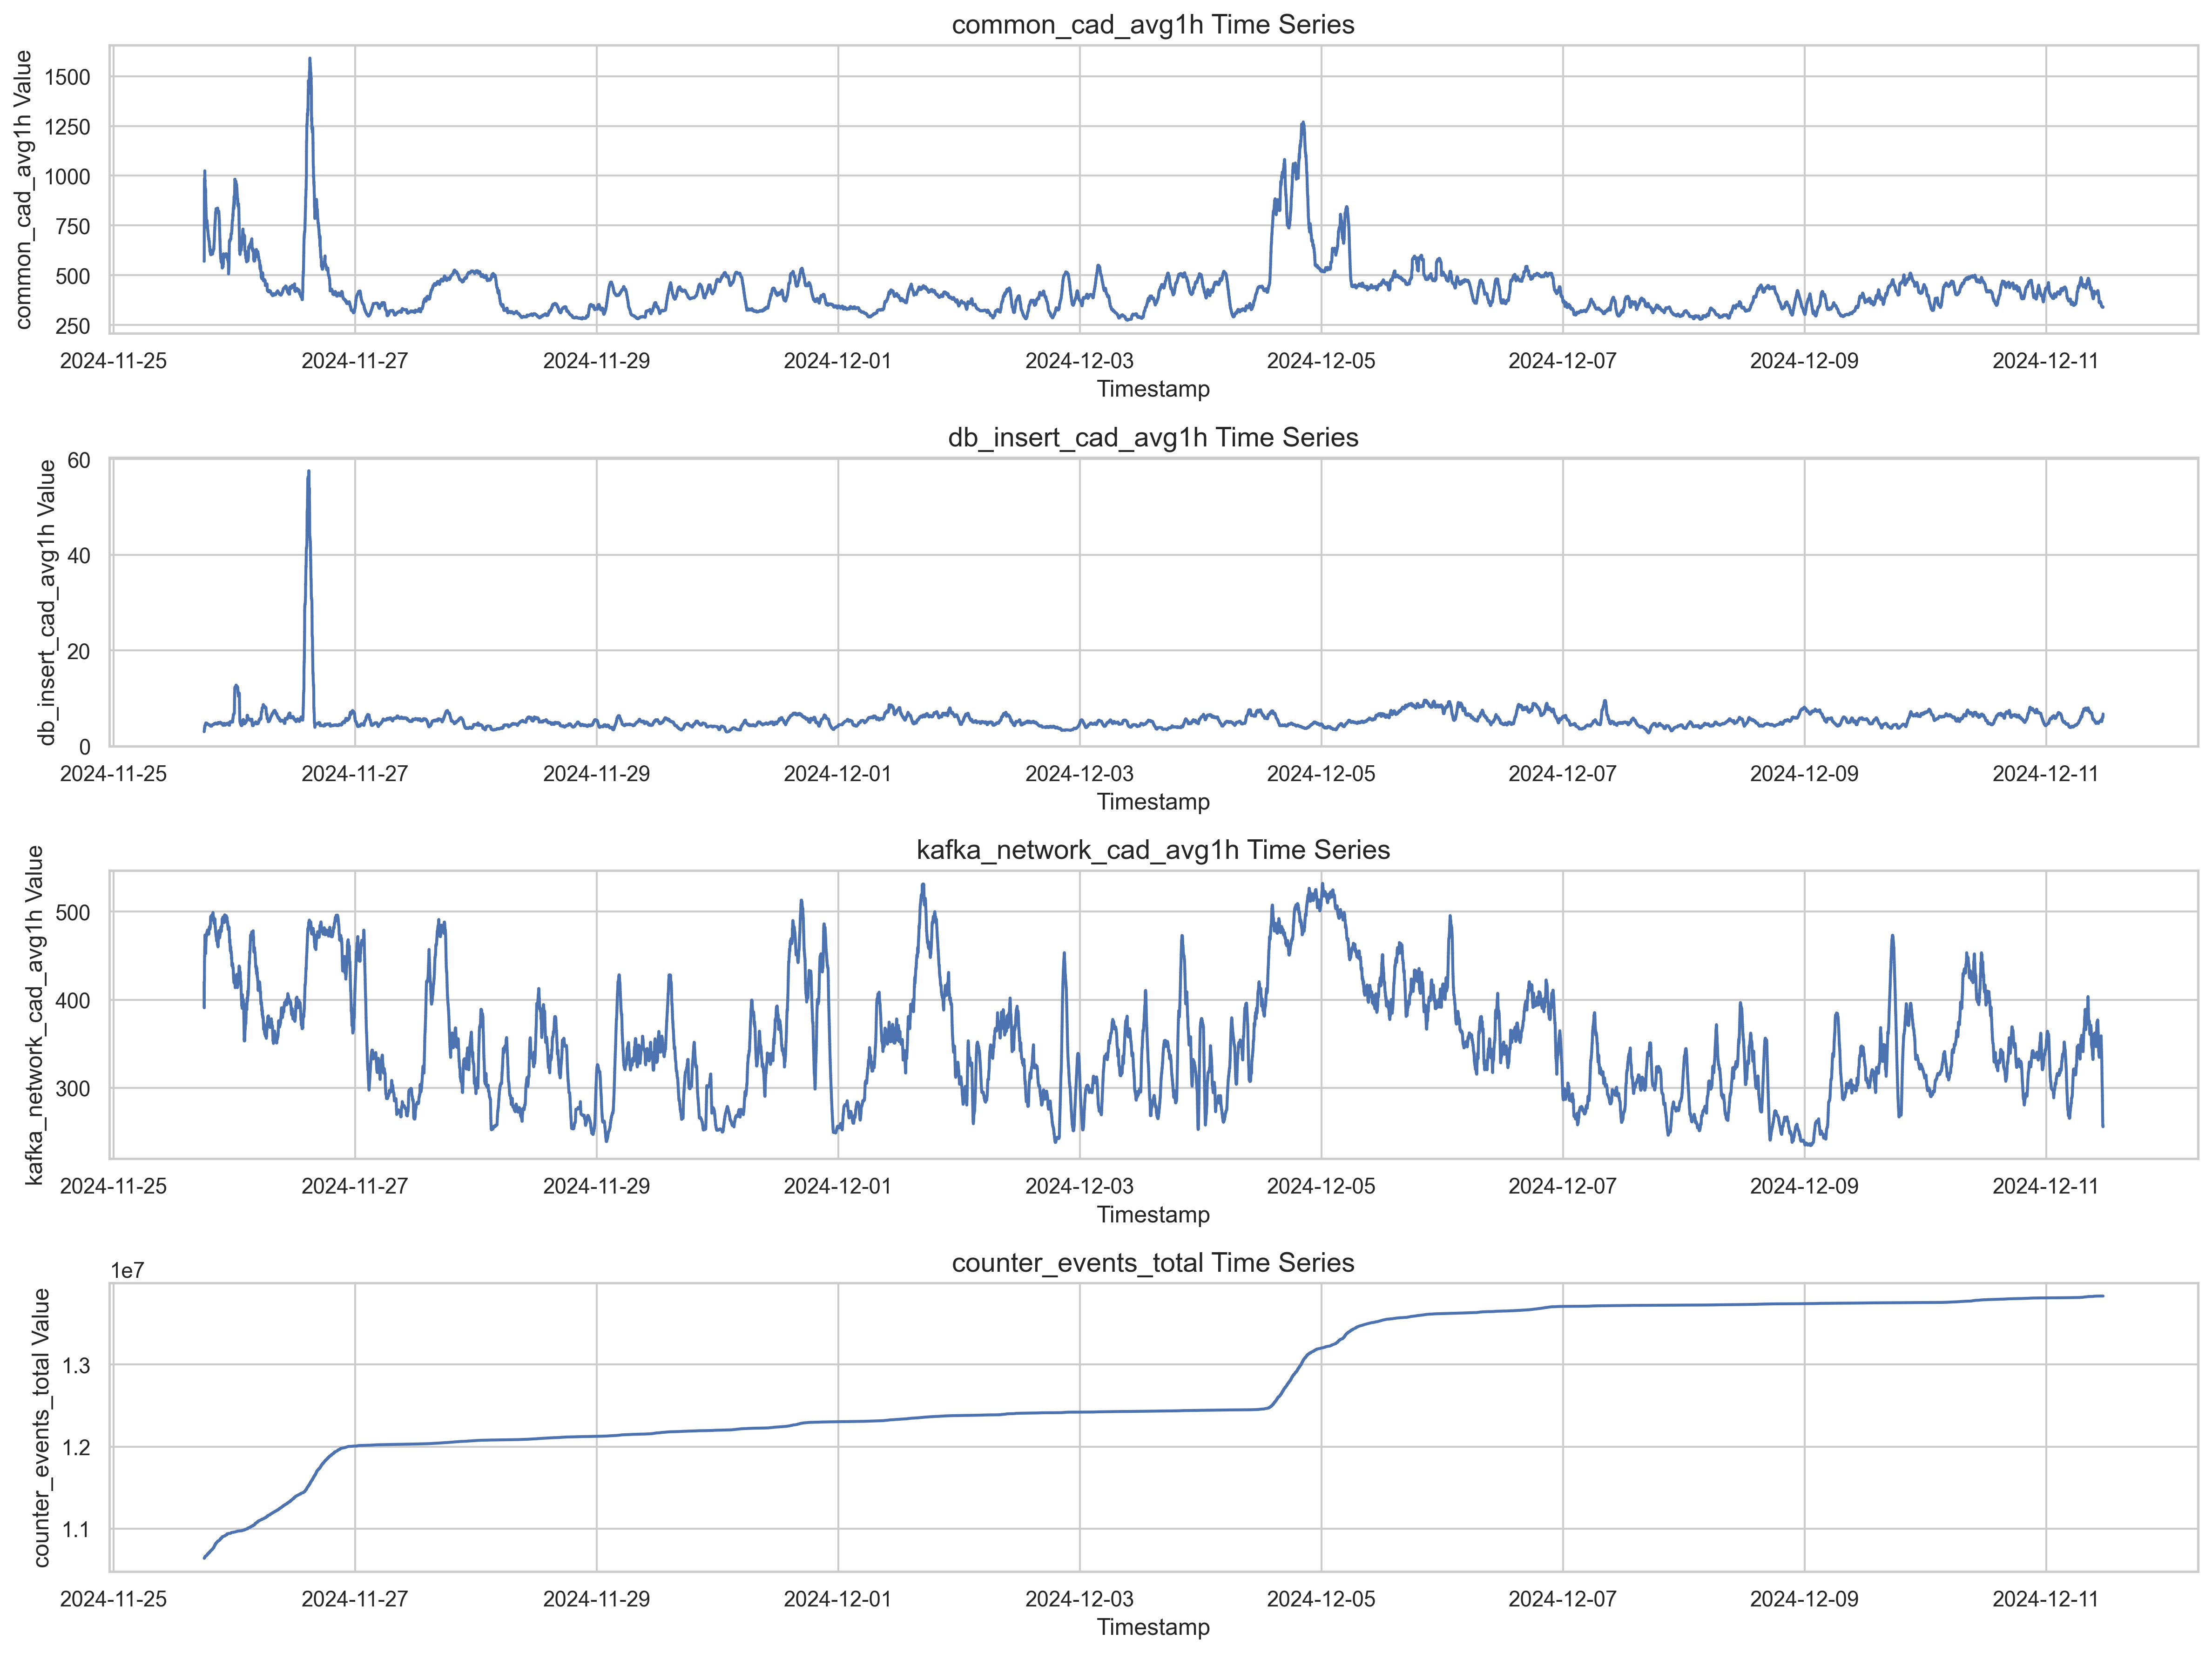

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.rcParams['figure.dpi'] = 300

# Set plot style
sns.set_theme(style="whitegrid")

# Plot all columns from df
columns = df.columns
n_cols = len(columns)
fig, axes = plt.subplots(n_cols, 1, figsize=(16, 3*n_cols))

if n_cols == 1:
    axes = [axes]

for i, col in enumerate(columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(f'{col} Time Series', fontsize=14)
    axes[i].set_xlabel('Timestamp', fontsize=12)
    axes[i].set_ylabel(f'{col} Value', fontsize=12)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

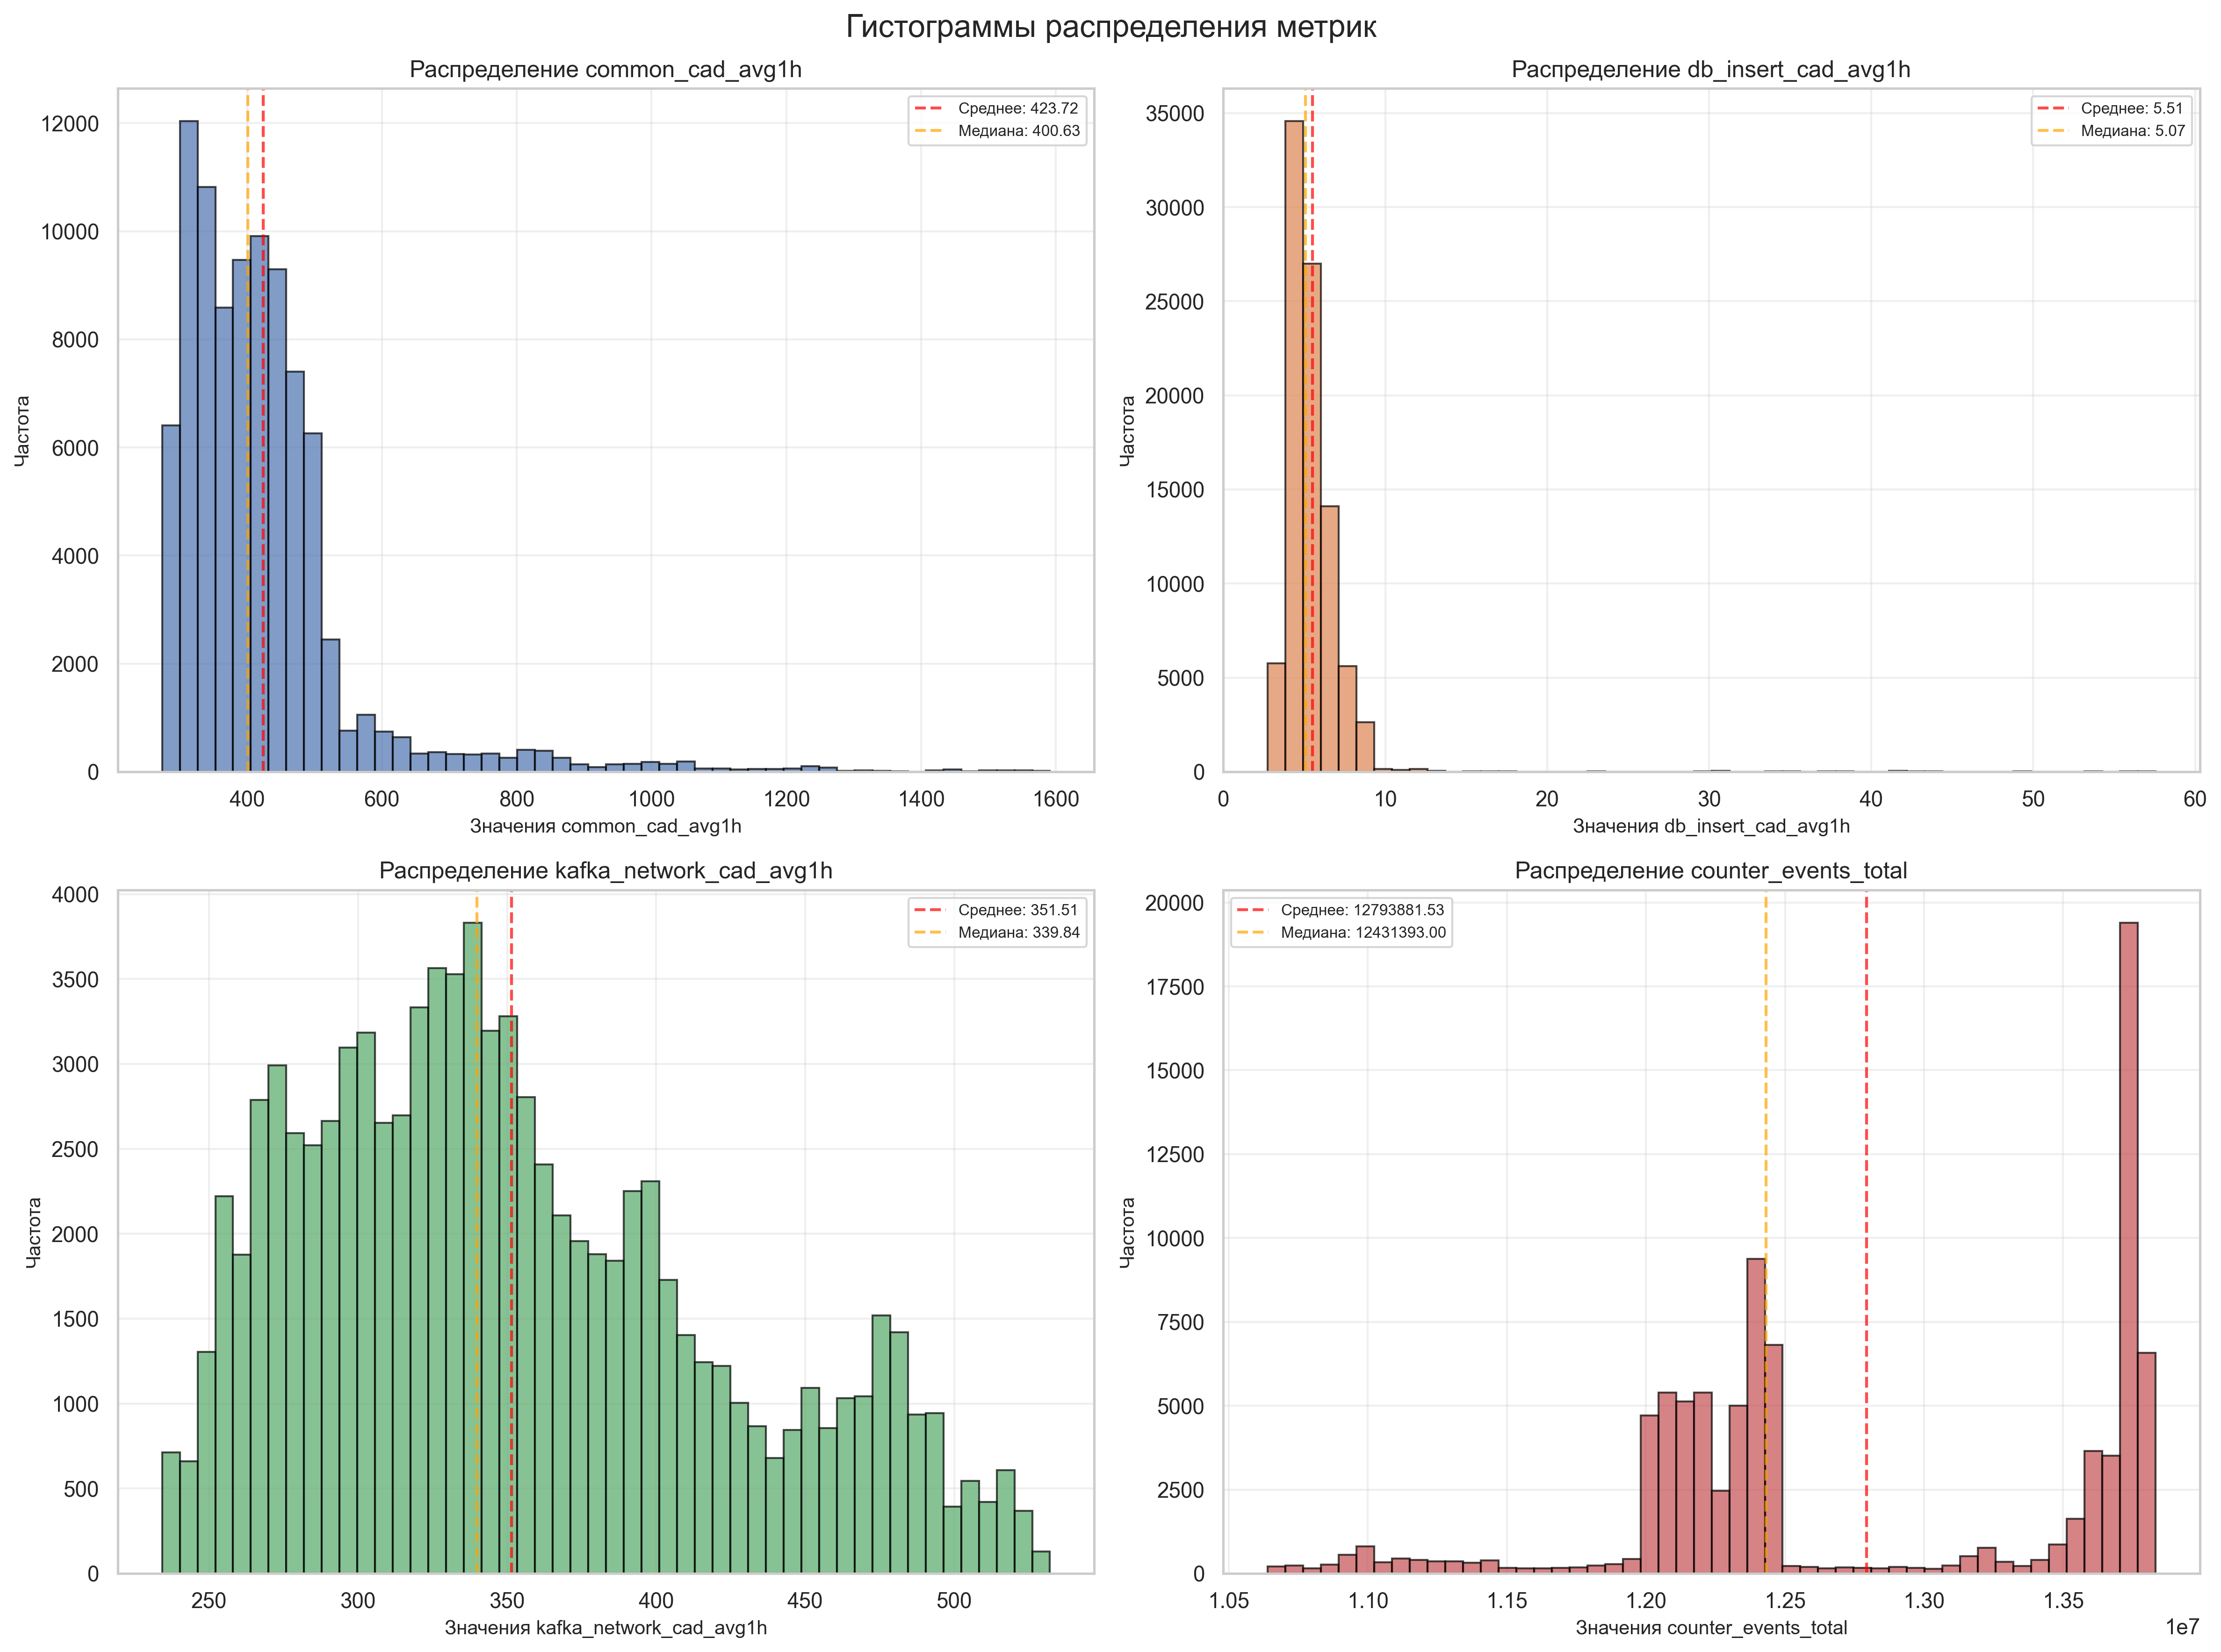

In [7]:
# Гистограммы распределения для всех 4 метрик
plt.figure(figsize=(16, 12))

metrics = ['common_cad_avg1h', 'db_insert_cad_avg1h', 'kafka_network_cad_avg1h', 'counter_events_total']

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    data = df[metric].dropna()
    
    plt.hist(data, bins=50, alpha=0.7, edgecolor='black', color=f'C{i-1}')
    plt.title(f'Распределение {metric}', fontsize=12)
    plt.xlabel(f'Значения {metric}', fontsize=10)
    plt.ylabel('Частота', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Добавляем статистику
    mean_val = data.mean()
    median_val = data.median()
    plt.axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Среднее: {mean_val:.2f}')
    plt.axvline(median_val, color='orange', linestyle='--', alpha=0.7, label=f'Медиана: {median_val:.2f}')
    plt.legend(fontsize=8)

plt.suptitle('Гистограммы распределения метрик', fontsize=16)
plt.tight_layout()
plt.show()

## 1 hour resampled data

Hourly resampled data info:
<class 'pandas.core.series.Series'>
DatetimeIndex: 378 entries, 2024-11-25 18:00:00 to 2024-12-11 11:00:00
Freq: h
Series name: common_cad_avg1h
Non-Null Count  Dtype  
--------------  -----  
378 non-null    float64
dtypes: float64(1)
memory usage: 5.9 KB

Missing values after resampling:
0


/var/folders/hz/g0q481y17153sdyxw9_71p380000gn/T/ipykernel_97506/3924981489.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['common_cad_avg1h'].resample('1H').mean().interpolate(method='time')


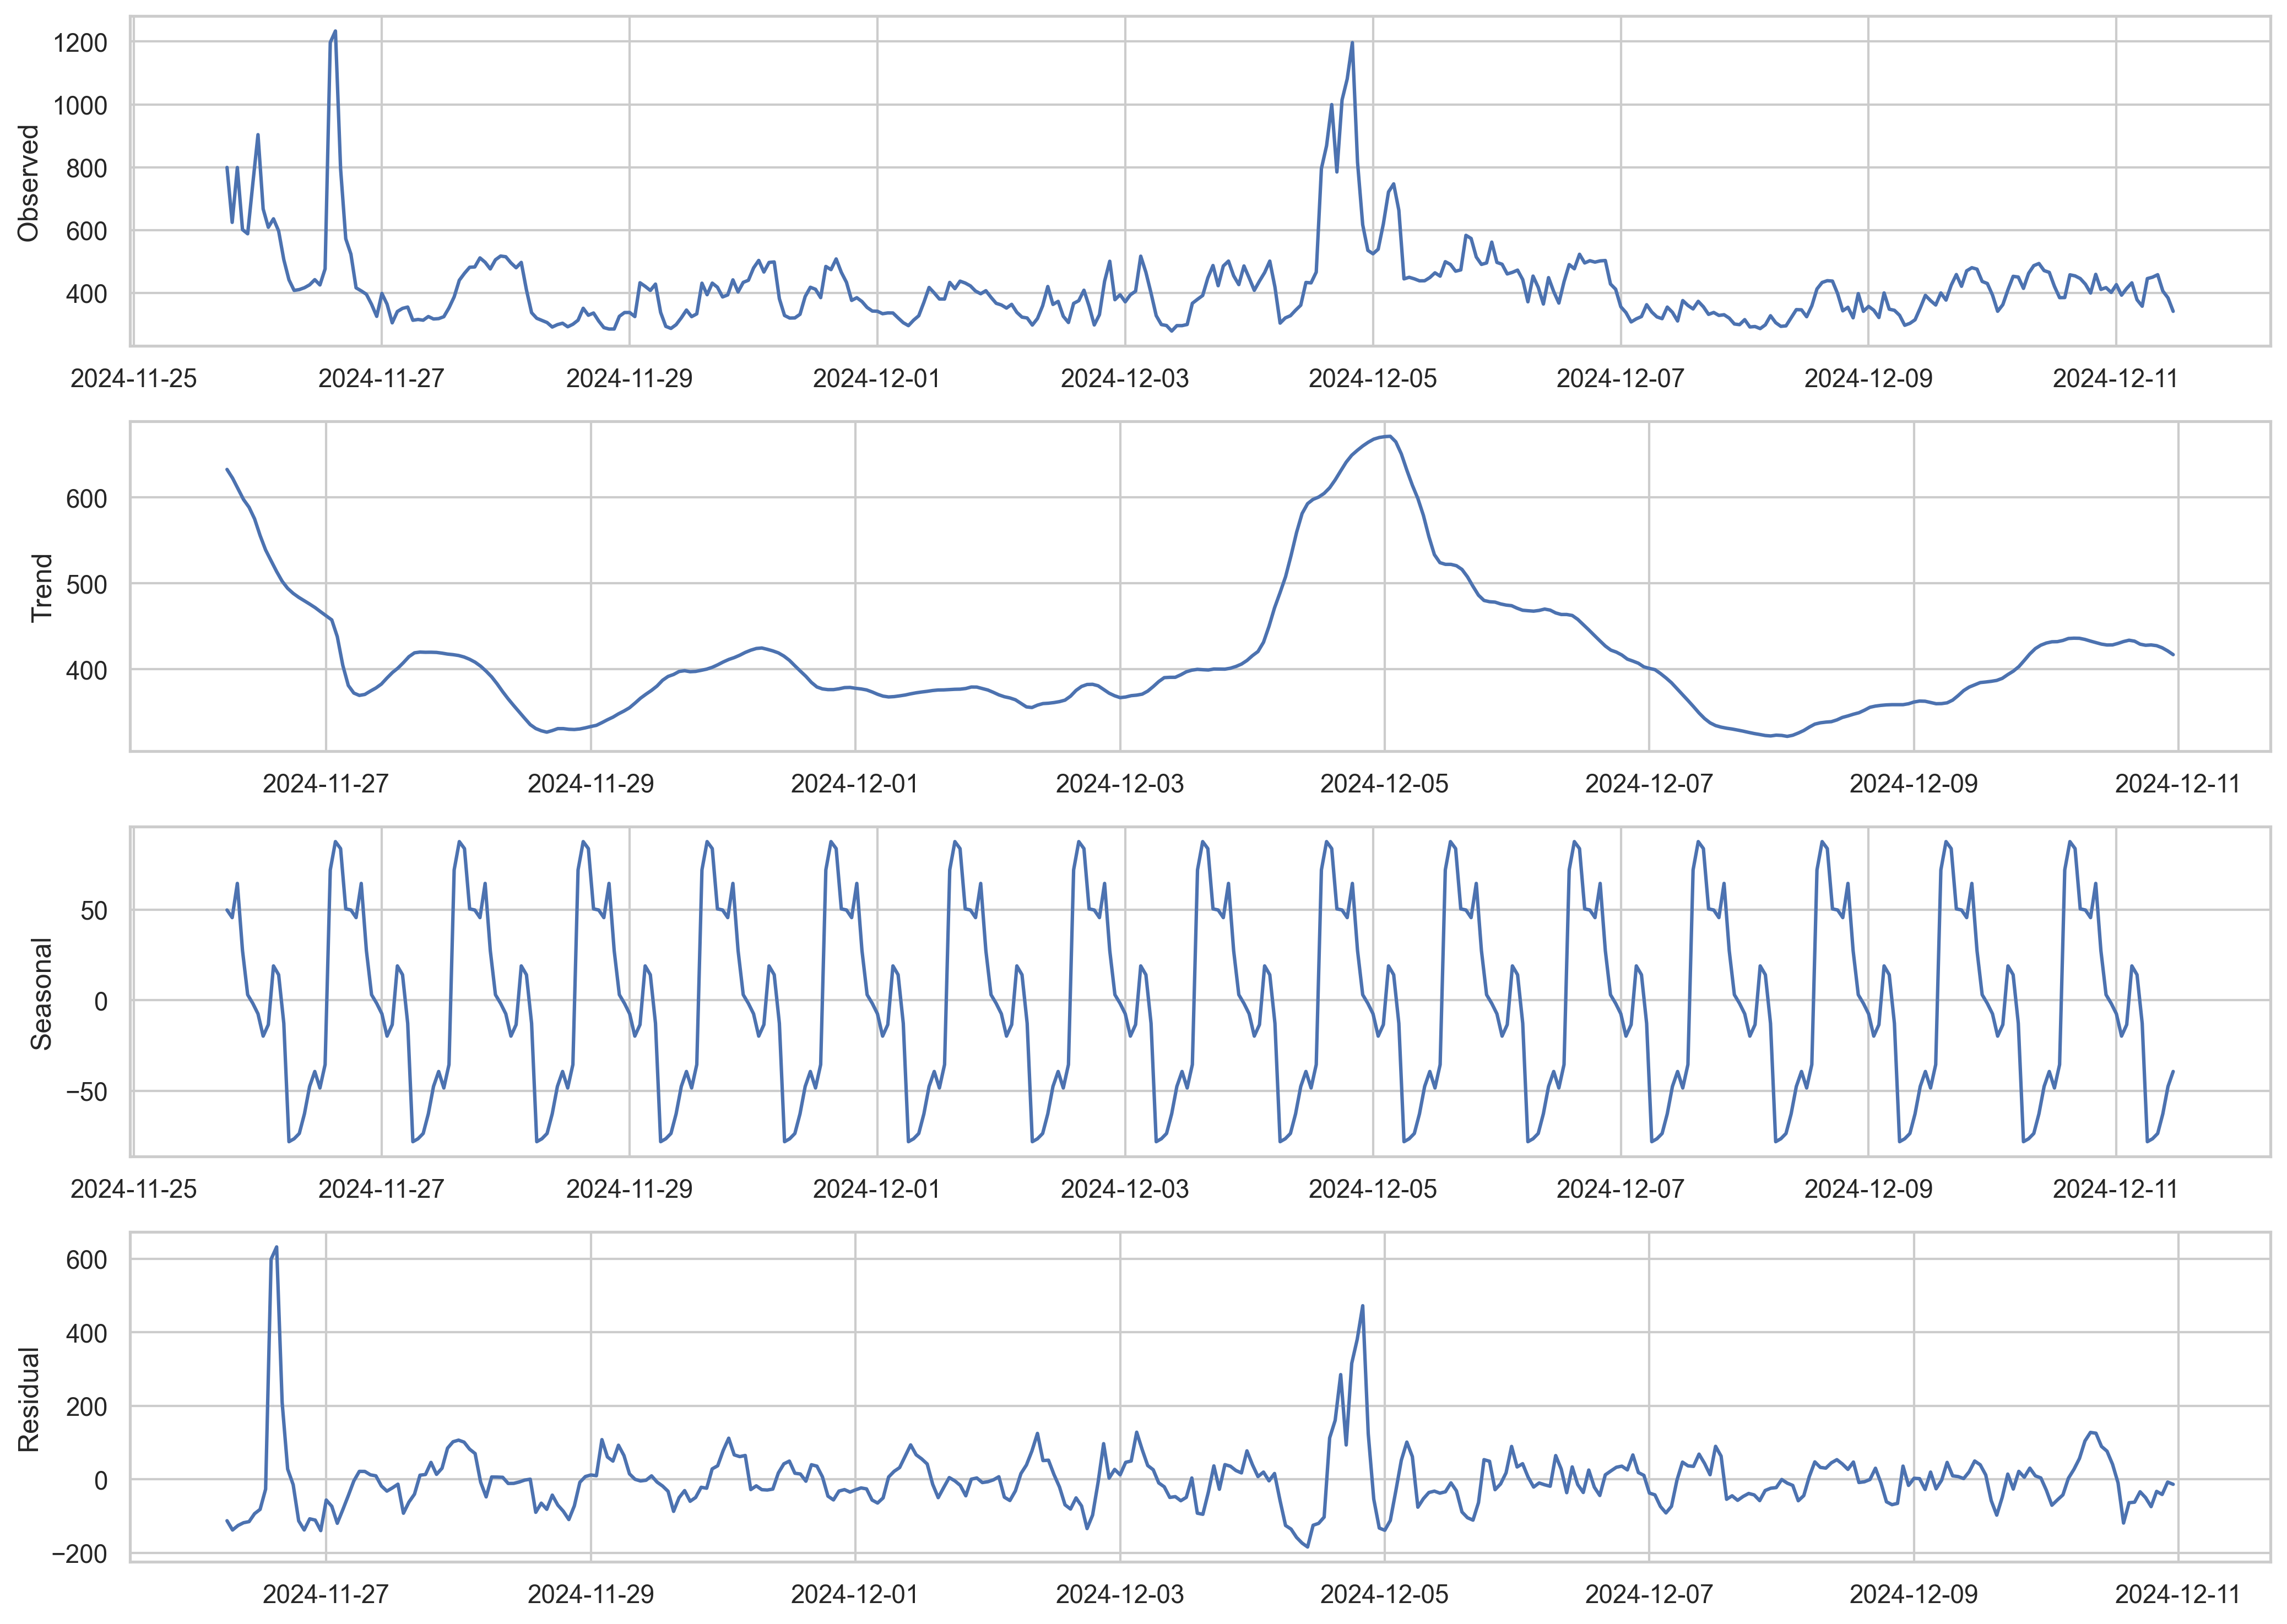

In [8]:

# Resample the data to an hourly frequency for easier analysis
df_hourly = df['common_cad_avg1h'].resample('1H').mean().interpolate(method='time')

print("Hourly resampled data info:")
df_hourly.info()
print("\nMissing values after resampling:")
print(df_hourly.isnull().sum())

# Perform seasonal decomposition (assuming daily seasonality for hourly data)
# Period for daily seasonality with hourly data is 24
decomposition = seasonal_decompose(df_hourly, model='additive', period=24)

# Plot decomposition
plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(decomposition.observed)
plt.ylabel('Observed')
plt.subplot(412)
plt.plot(decomposition.trend)
plt.ylabel('Trend')
plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.ylabel('Seasonal')
plt.subplot(414)
plt.plot(decomposition.resid)
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

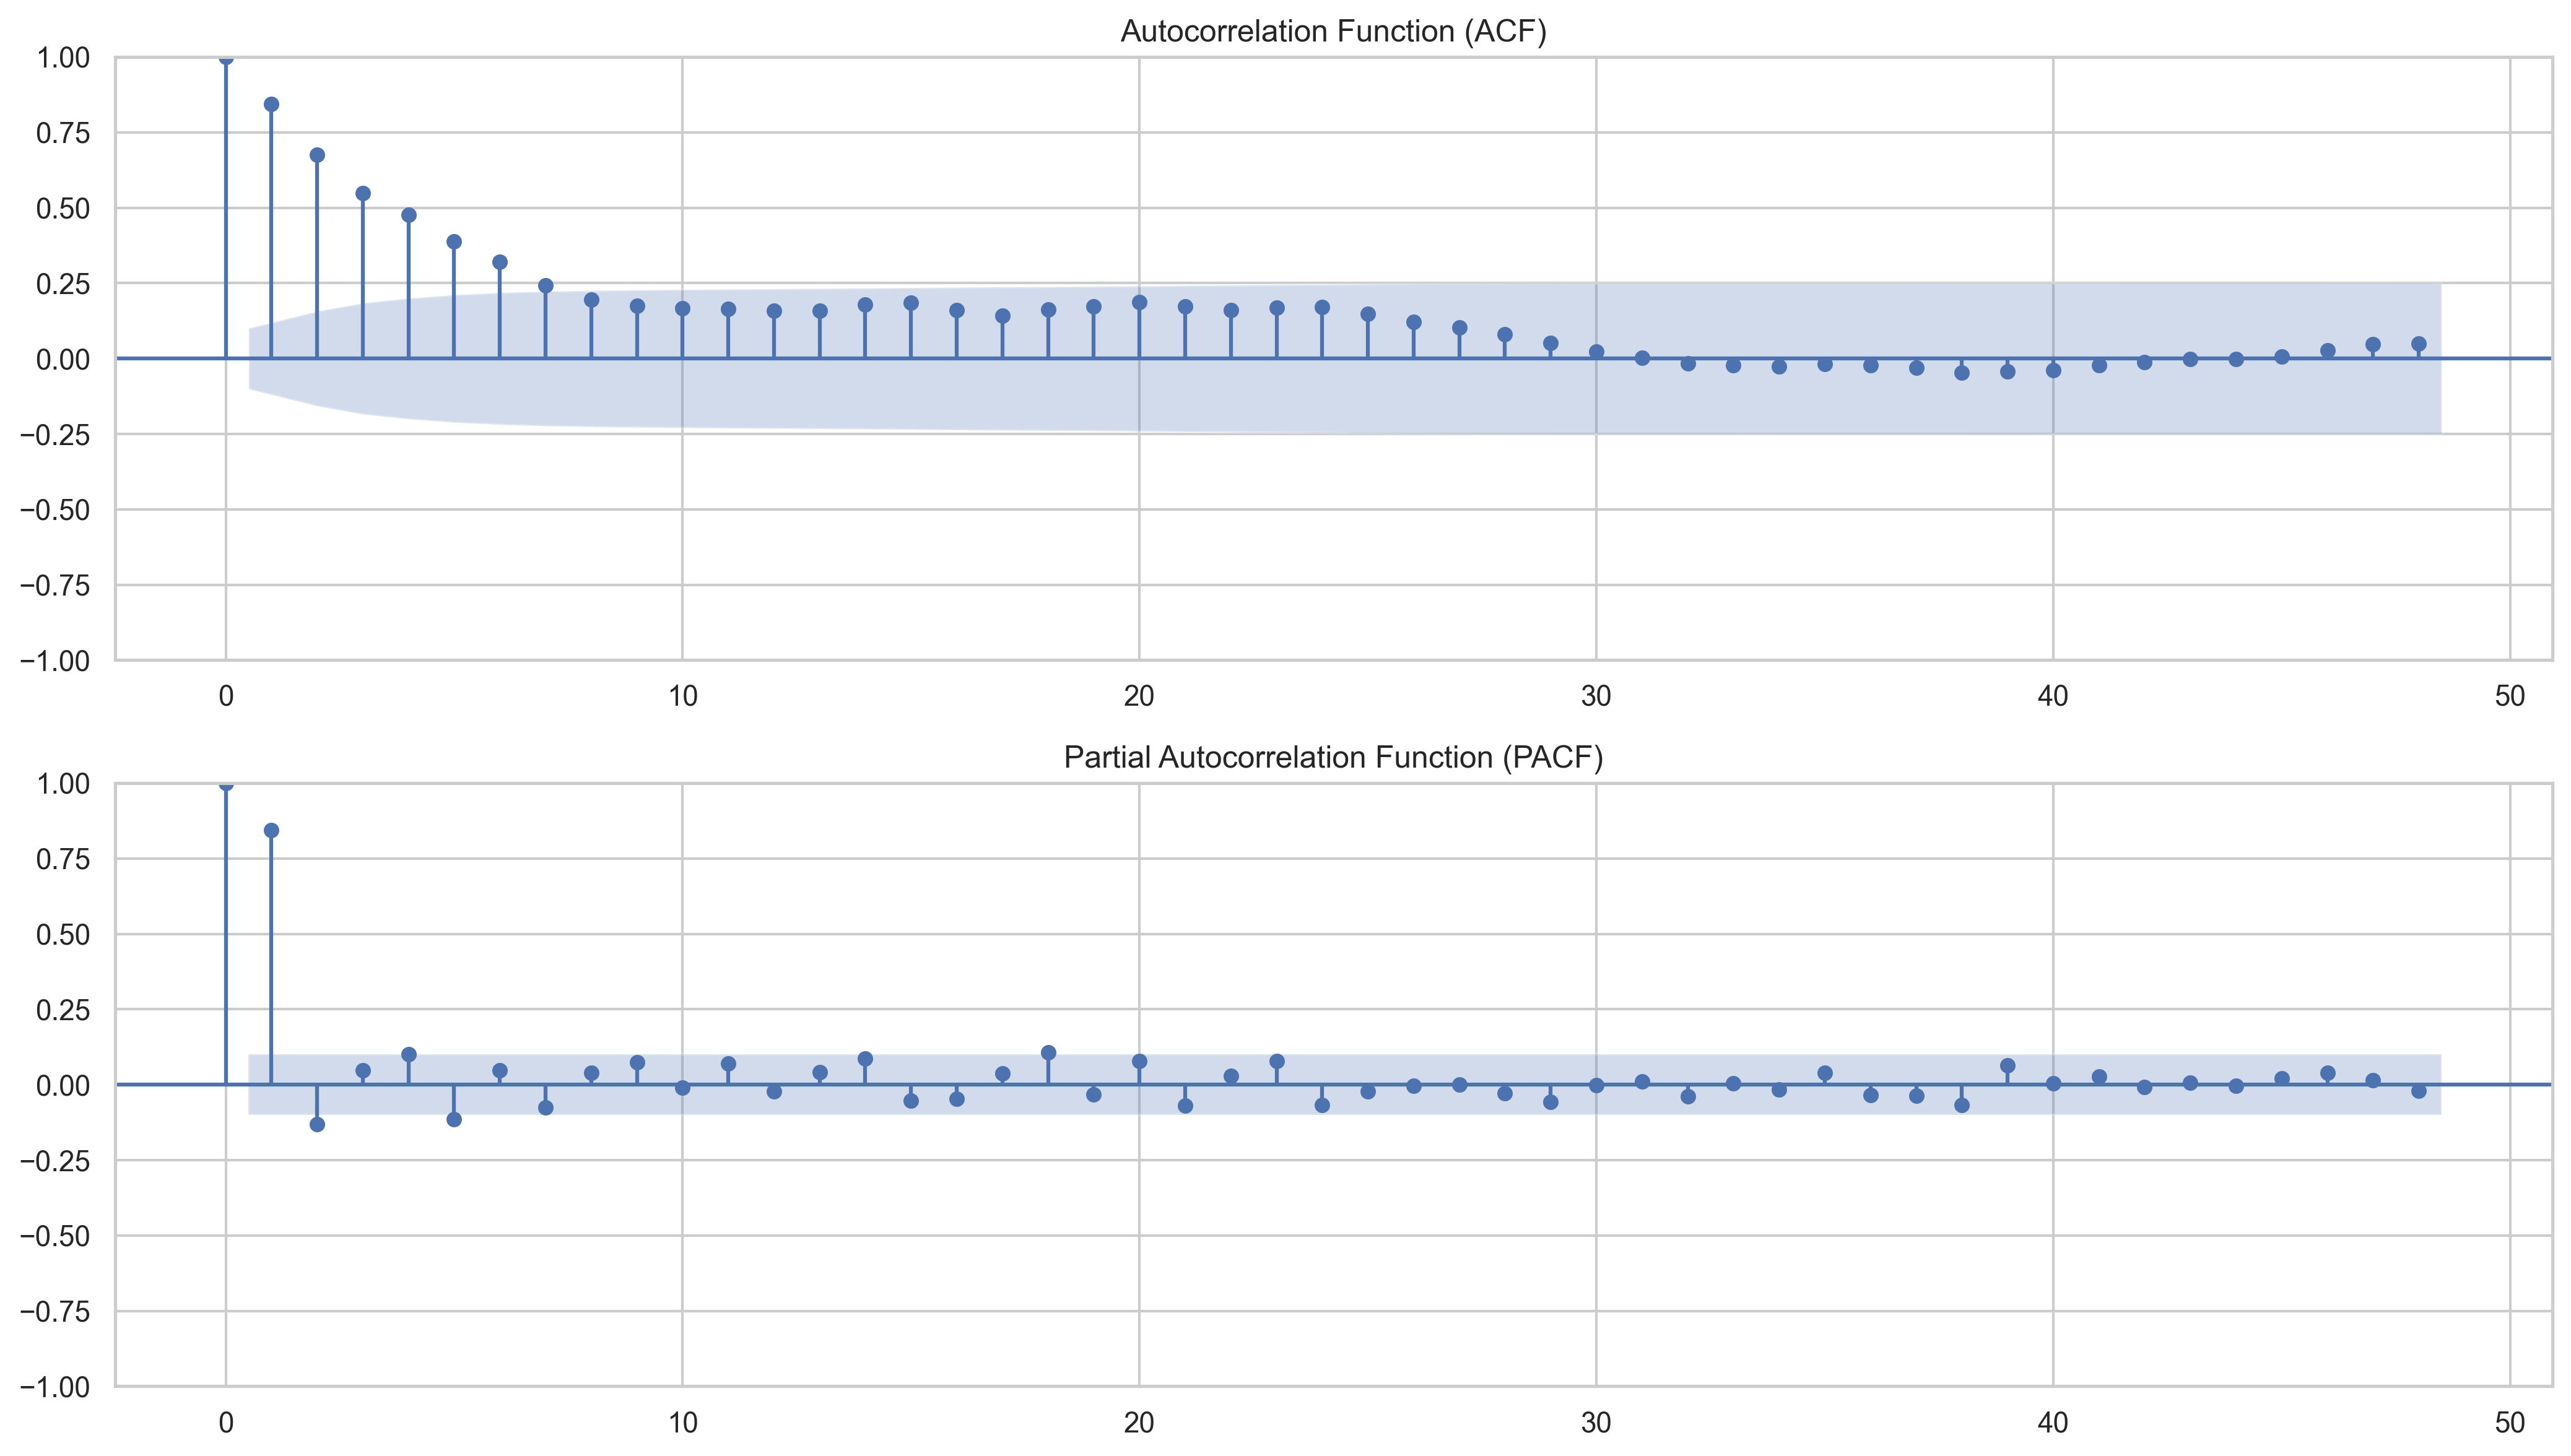

In [9]:
# Plot ACF and PACF to identify potential AR/MA components and seasonality
plt.figure(figsize=(14, 8))
plt.subplot(211)
plot_acf(df_hourly.dropna(), lags=48, ax=plt.gca(), title='Autocorrelation Function (ACF)')
plt.subplot(212)
plot_pacf(df_hourly.dropna(), lags=48, ax=plt.gca(), title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

## Анализ исходного временного ряда (без ресемплинга)

Анализируем оригинальные данные с интервалом 15 секунд - как есть.


In [10]:

# Базовая информация об исходном ряде
print("=== Информация о исходном временном ряде ===")
print(f"Общее количество точек: {len(df)}")
print(f"Период данных: {df.index.min()} - {df.index.max()}")
print(f"Временной интервал между точками: {df.index.to_series().diff().mode()[0]}")
print(f"Пропущенные значения: {df['common_cad_avg1h'].isnull().sum()}")

# Базовая статистика
print("\n=== Основная статистика ===")
print(df['common_cad_avg1h'].describe())

# Проверим частоту данных
time_diffs = df.index.to_series().diff().dropna()
print(f"\nЧастота данных:")
print(f"Медианный интервал: {time_diffs.median()}")
print(f"Минимальный интервал: {time_diffs.min()}")
print(f"Максимальный интервал: {time_diffs.max()}")
print(f"Стандартное отклонение интервалов: {time_diffs.std()}")


print("\nПроверка на дубликаты во временном индексе:")
print(f"Количество дубликатов в индексе: {df.index.duplicated().sum()}")
if df.index.duplicated().any():
    print("Внимание: Обнаружены дубликаты во временном индексе. Обрабатываю...")
    # Удаляем дубликаты, оставляя последнее значение, или усредняем
    df = df.loc[~df.index.duplicated(keep='last')] # или .mean() если усреднение
    # df = df.resample('15S').mean() # Альтернативный способ, если нужны все 15s интервалы, даже пропущенные
    print(f"Количество точек после обработки дубликатов: {len(df)}")


=== Информация о исходном временном ряде ===
Общее количество точек: 90543
Период данных: 2024-11-25 18:01:00 - 2024-12-11 11:16:30
Временной интервал между точками: 0 days 00:00:15
Пропущенные значения: 0

=== Основная статистика ===
count    90543.000000
mean       423.721359
std        138.113803
min        273.657007
25%        334.750260
50%        400.631922
75%        463.068981
max       1591.184778
Name: common_cad_avg1h, dtype: float64

Частота данных:
Медианный интервал: 0 days 00:00:15
Минимальный интервал: 0 days 00:00:15
Максимальный интервал: 0 days 00:00:15
Стандартное отклонение интервалов: 0 days 00:00:00

Проверка на дубликаты во временном индексе:
Количество дубликатов в индексе: 0


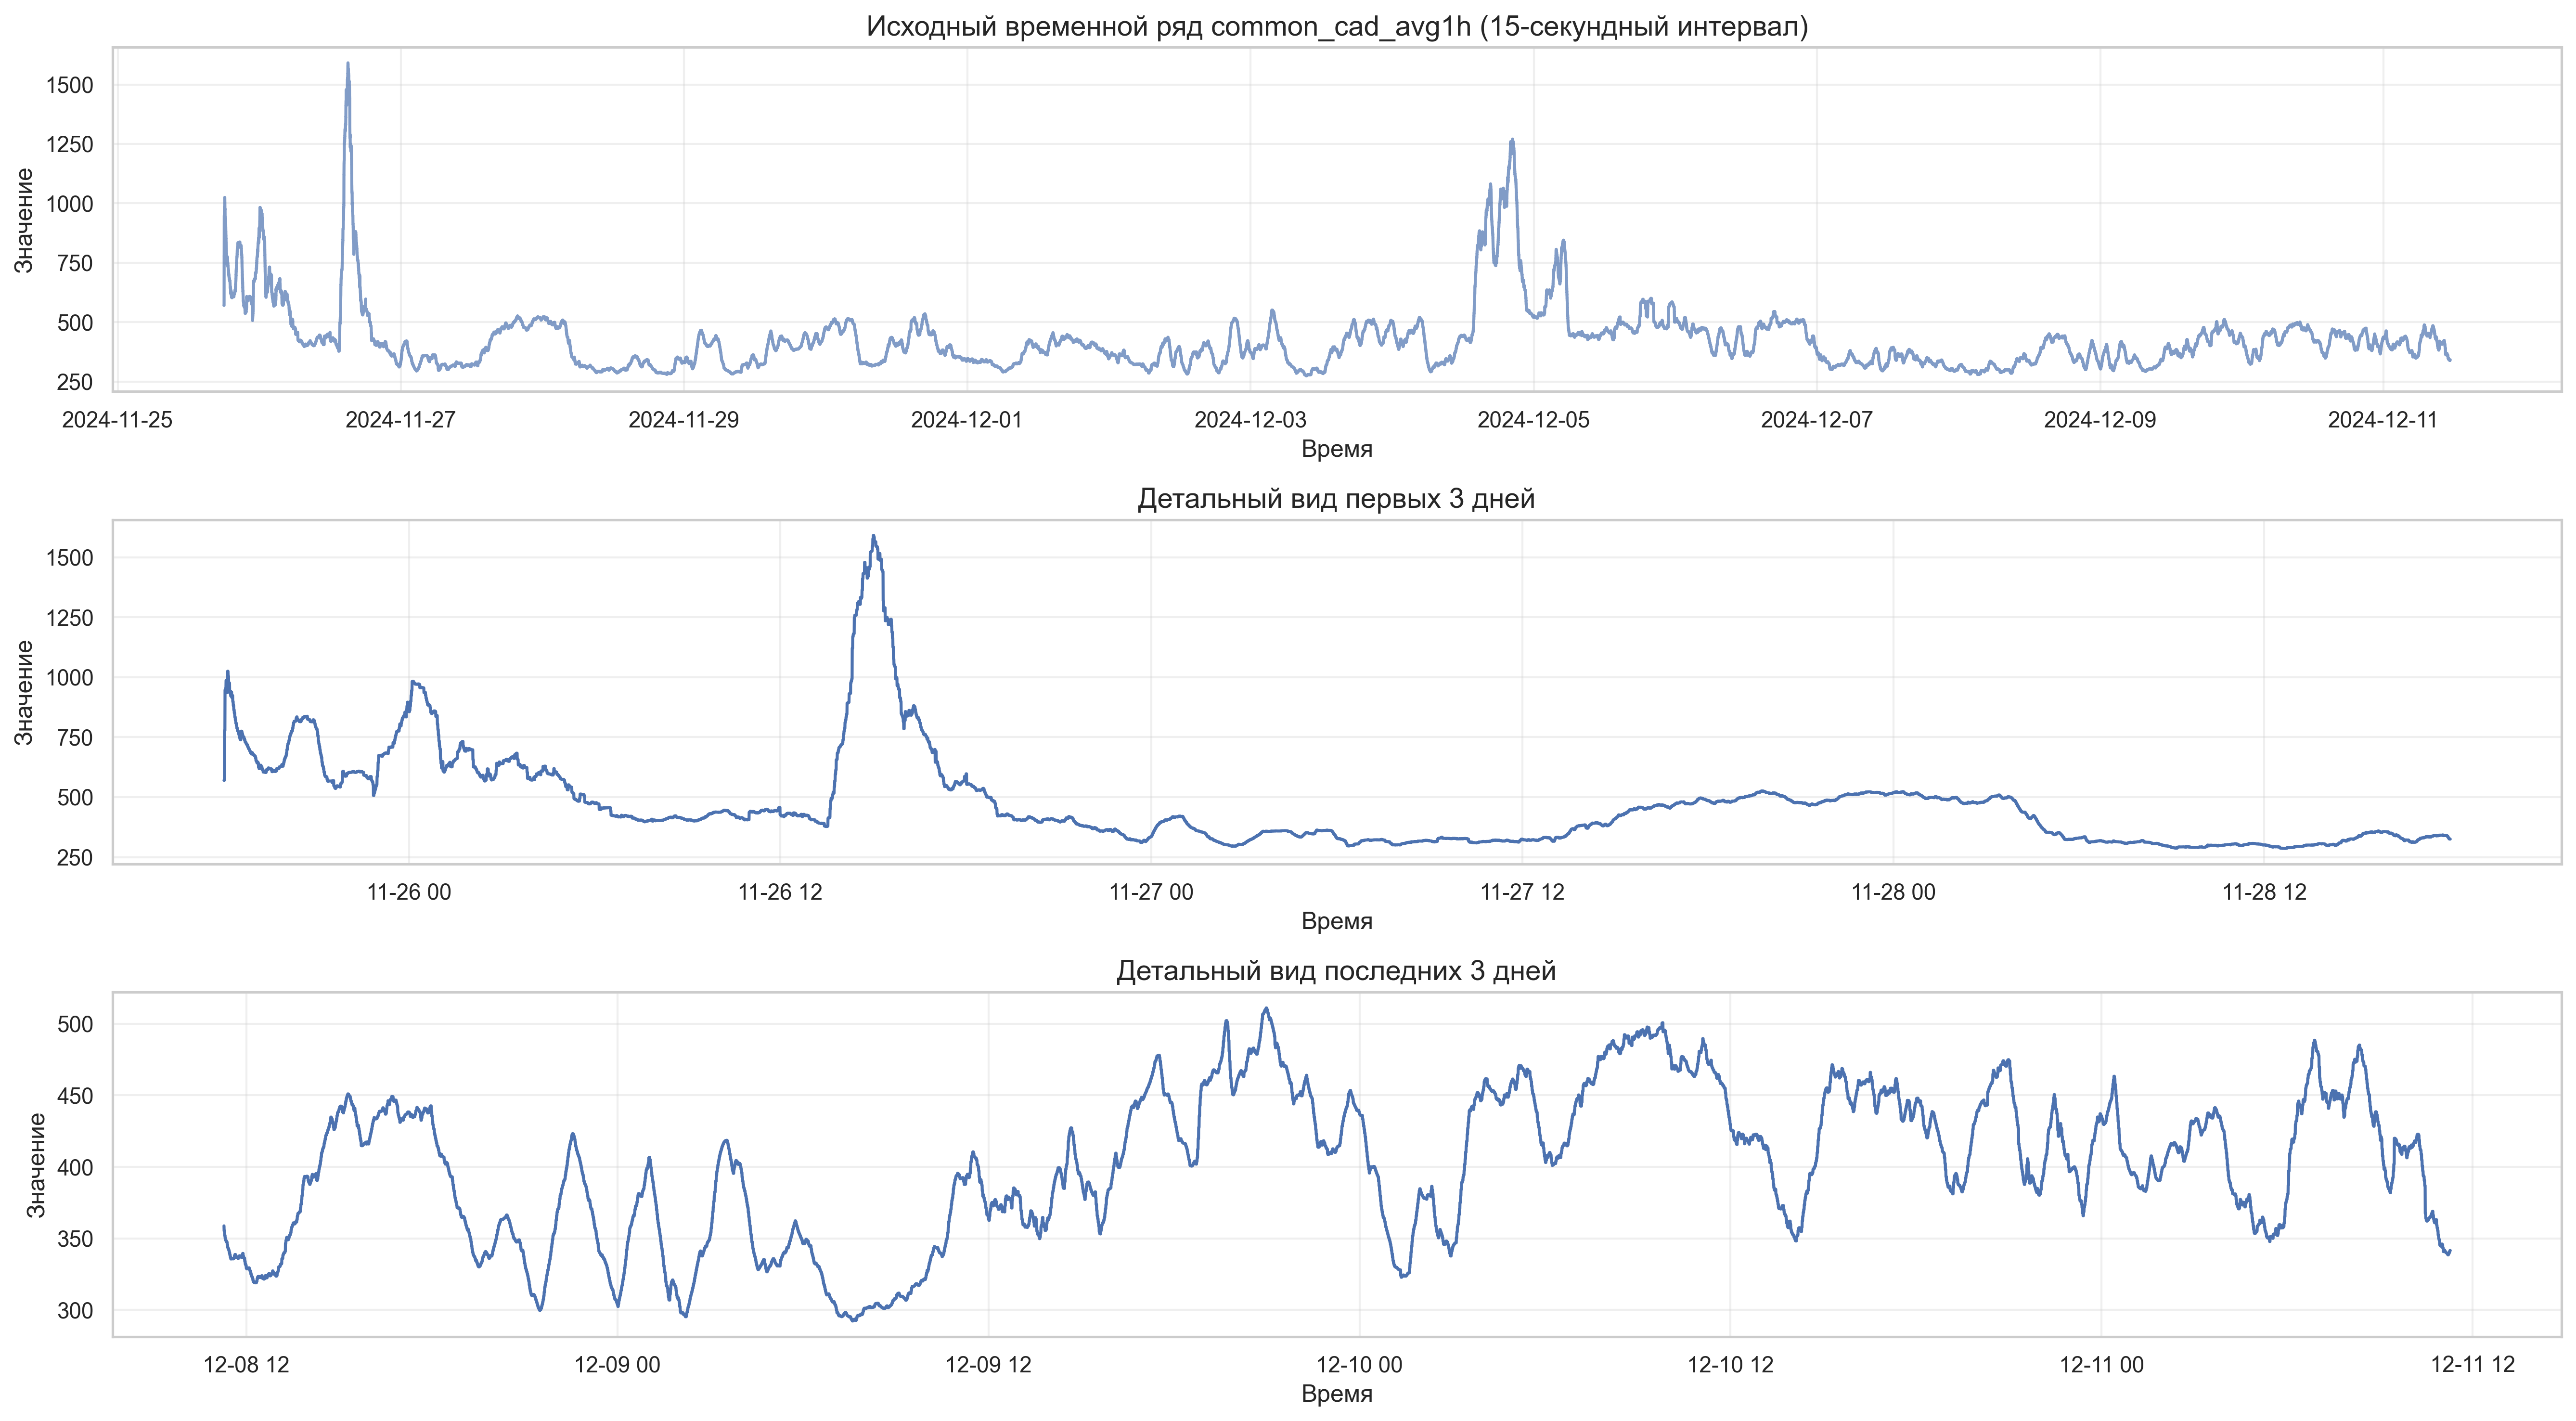

In [11]:
# Визуализация оригинального временного ряда
plt.figure(figsize=(18, 10))

# 1. Полный ряд
plt.subplot(3, 1, 1)
sns.lineplot(data=df, x=df.index, y='common_cad_avg1h', alpha=0.7)
plt.title('Исходный временной ряд common_cad_avg1h (15-секундный интервал)', fontsize=14)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)

# 2. Приближение на первые 3 дня
plt.subplot(3, 1, 2)
first_3_days = df.head(17280)  # примерно 3 дня * 24 часа * 240 точек в час
sns.lineplot(data=first_3_days, x=first_3_days.index, y='common_cad_avg1h')
plt.title('Детальный вид первых 3 дней', fontsize=14)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)

# 3. Последние 3 дня
plt.subplot(3, 1, 3)
last_3_days = df.tail(17280)
sns.lineplot(data=last_3_days, x=last_3_days.index, y='common_cad_avg1h')
plt.title('Детальный вид последних 3 дней', fontsize=14)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Используется подвыборка: усреднение до 1-минутного интервала
Размер выборки: 22636 точек
Период для сезонной декомпозиции: 1440


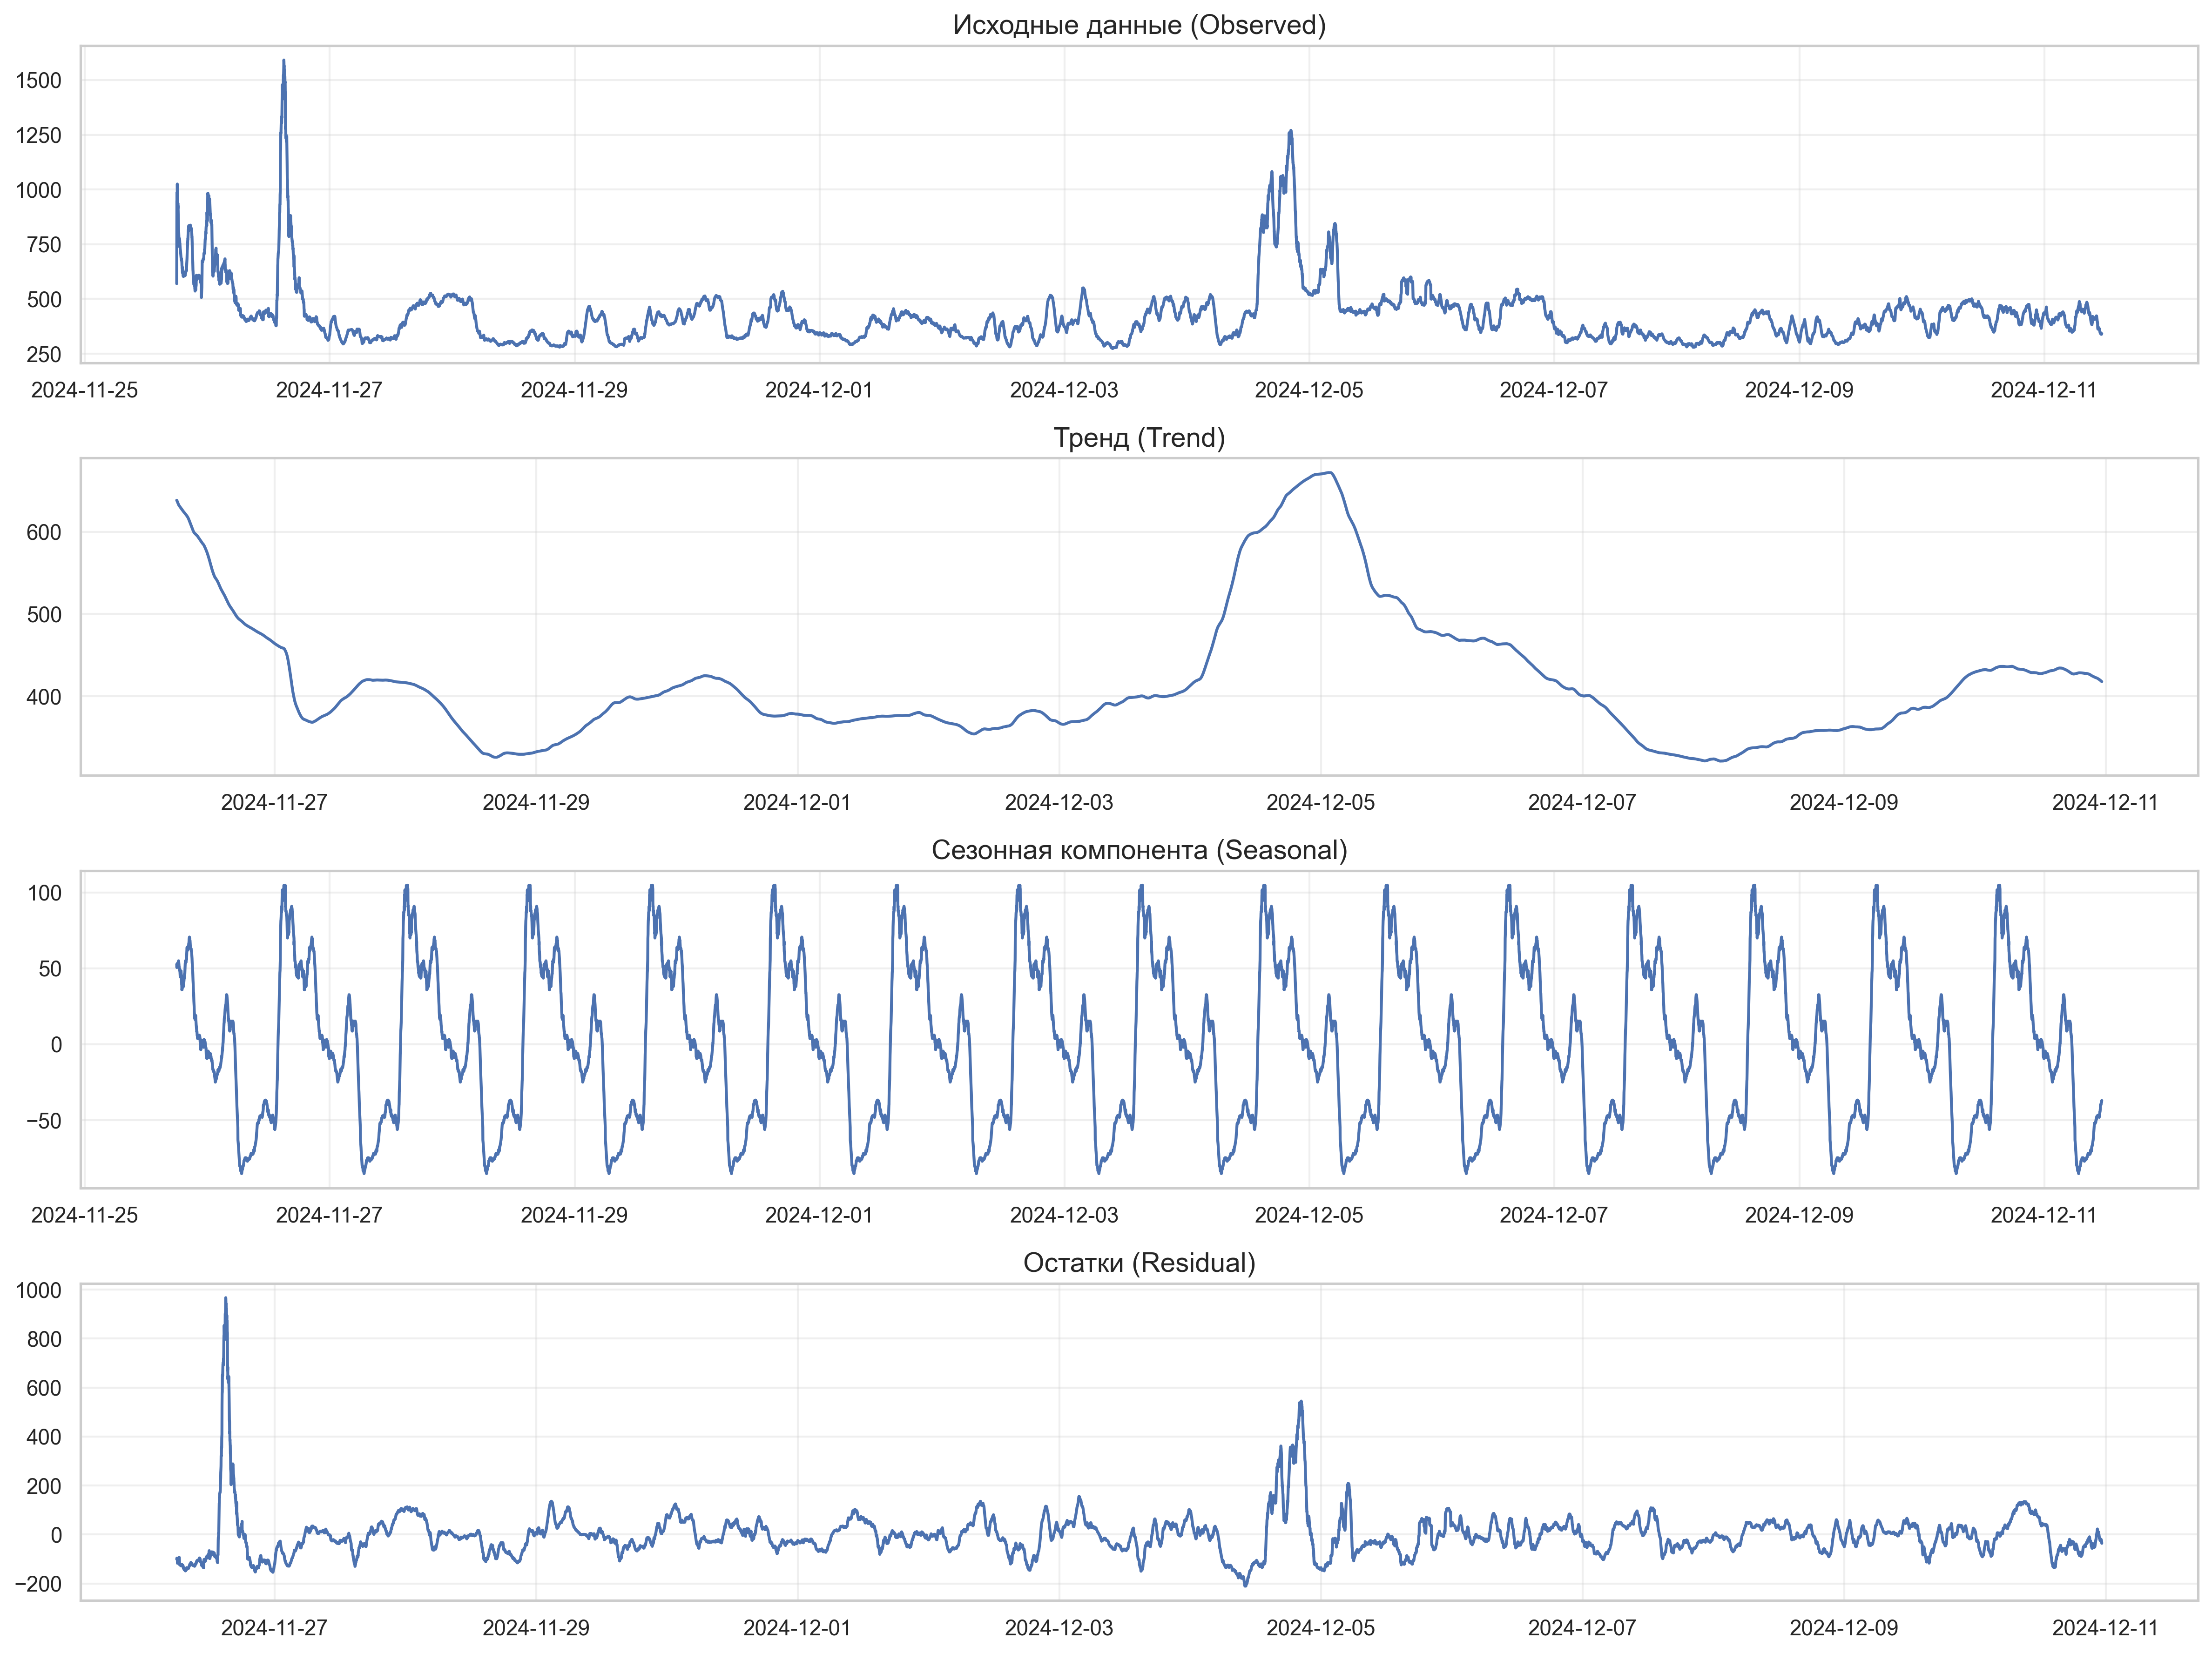

In [12]:
# Сезонная декомпозиция на исходных данных
# Для данных с интервалом 15 секунд:
# - В одном часе: 240 точек (3600 сек / 15 сек)
# - В одном дне: 5760 точек (24 * 240)

# Возьмем подвыборку для декомпозиции (слишком много данных для полного анализа)
# Возьмем данные за 7 дней для анализа недельной сезонности
week_data = df['common_cad_avg1h'].dropna()

# Если данных слишком много, усредним до 1-минутного интервала
if len(week_data) > 50000:
    # Усредняем каждые 4 точки для получения 1-минутных данных
    week_data_sample = week_data.resample('1min').mean()
    print(f"Используется подвыборка: усреднение до 1-минутного интервала")
    print(f"Размер выборки: {len(week_data_sample)} точек")
    period = 1440  # 24 часа * 60 минут = дневная сезонность
else:
    week_data_sample = week_data
    period = 5760  # дневная сезонность для 15-секундных данных

print(f"Период для сезонной декомпозиции: {period}")

# Сезонная декомпозиция
decomposition = seasonal_decompose(week_data_sample, model='additive', period=period)

# Визуализация декомпозиции
plt.figure(figsize=(16, 12))

plt.subplot(411)
plt.plot(decomposition.observed)
plt.title('Исходные данные (Observed)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(412)
plt.plot(decomposition.trend)
plt.title('Тренд (Trend)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title('Сезонная компонента (Seasonal)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(414)
plt.plot(decomposition.resid)
plt.title('Остатки (Residual)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


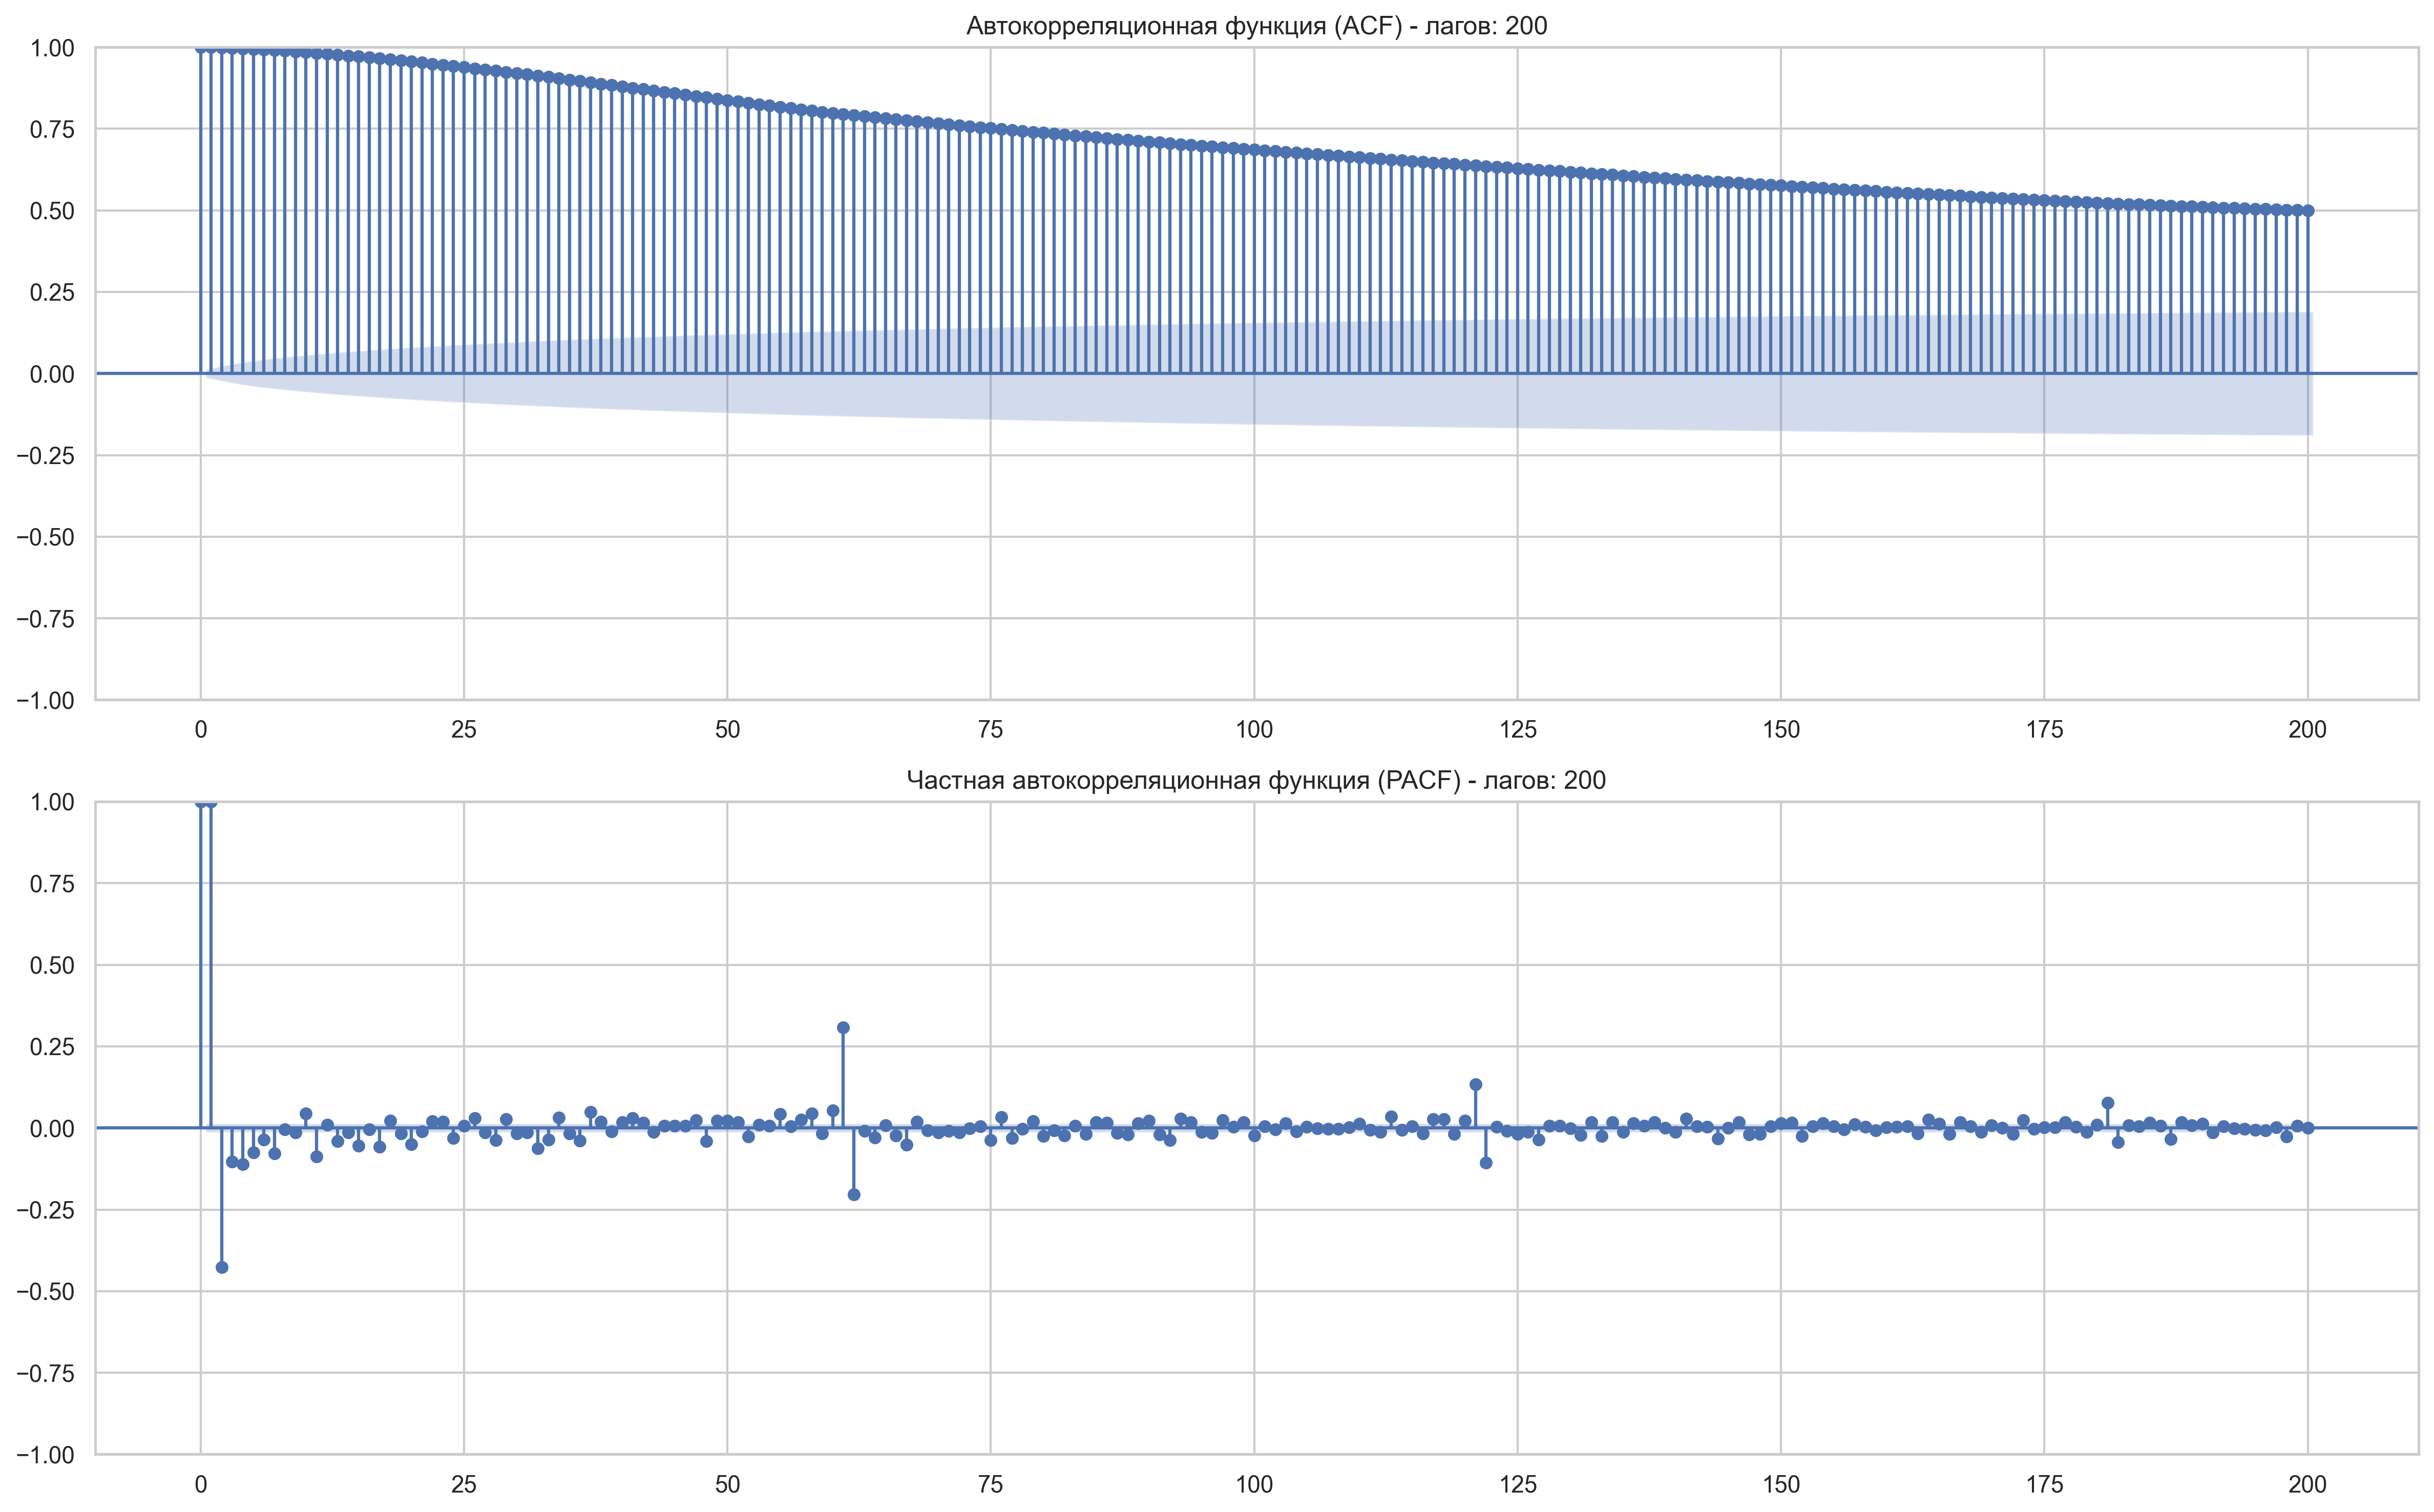

Анализ корреляций для 22636 точек данных
Максимальный лаг: 200 (примерно 3.3 часов для 1-минутных данных)


In [13]:
# ACF/PACF анализ для исходных данных
# Возьмем подвыборку для корреляционного анализа
sample_for_acf = week_data_sample.dropna()

# Лагов на 2 дня (для 1-минутных данных: 2880 точек, но ограничим до 200 для читаемости)
max_lags = min(200, len(sample_for_acf) // 4)

plt.figure(figsize=(16, 10))

# ACF
plt.subplot(2, 1, 1)
plot_acf(sample_for_acf, lags=max_lags, ax=plt.gca(), 
         title=f'Автокорреляционная функция (ACF) - лагов: {max_lags}')

# PACF
plt.subplot(2, 1, 2)
plot_pacf(sample_for_acf, lags=max_lags, ax=plt.gca(), 
          title=f'Частная автокорреляционная функция (PACF) - лагов: {max_lags}')

plt.tight_layout()
plt.show()

print(f"Анализ корреляций для {len(sample_for_acf)} точек данных")
print(f"Максимальный лаг: {max_lags} (примерно {max_lags/60:.1f} часов для 1-минутных данных)")


In [14]:
# Дополнительный статистический анализ
import numpy as np
from scipy import stats

raw_data = df['common_cad_avg1h'].dropna()

print("=== Расширенный статистический анализ ===")
print(f"Количество наблюдений: {len(raw_data)}")
print(f"Среднее: {raw_data.mean():.3f}")
print(f"Медиана: {raw_data.median():.3f}")
print(f"Стандартное отклонение: {raw_data.std():.3f}")
print(f"Коэффициент вариации: {(raw_data.std()/raw_data.mean())*100:.2f}%")
print(f"Асимметрия (skewness): {stats.skew(raw_data):.3f}")
print(f"Эксцесс (kurtosis): {stats.kurtosis(raw_data):.3f}")

# Процентили
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print(f"\nПроцентили:")
for p in percentiles:
    value = np.percentile(raw_data, p)
    print(f"P{p}: {value:.3f}")

# Тест на нормальность
shapiro_stat, shapiro_p = stats.shapiro(raw_data[:5000])  # ограничиваем размер для теста
print(f"\nТест Шапиро-Уилка на нормальность (первые 5000 точек):")
print(f"Статистика: {shapiro_stat:.6f}, p-value: {shapiro_p:.6f}")
print(f"Данные {'НЕ ' if shapiro_p < 0.05 else ''}распределены нормально (α=0.05)")


=== Расширенный статистический анализ ===
Количество наблюдений: 90543
Среднее: 423.721
Медиана: 400.632
Стандартное отклонение: 138.114
Коэффициент вариации: 32.60%
Асимметрия (skewness): 3.127
Эксцесс (kurtosis): 14.467

Процентили:
P1: 284.698
P5: 295.817
P10: 306.820
P25: 334.750
P50: 400.632
P75: 463.069
P90: 519.976
P95: 656.625
P99: 1036.016

Тест Шапиро-Уилка на нормальность (первые 5000 точек):
Статистика: 0.854848, p-value: 0.000000
Данные НЕ распределены нормально (α=0.05)


common_cad_avg1h:
  Выбросы: 4540 (5.01%)
  Границы: [142.272, 655.547]
  Мин/Макс выброс: 655.569 / 1591.185

db_insert_cad_avg1h:
  Выбросы: 2340 (2.58%)
  Границы: [2.030, 8.489]
  Мин/Макс выброс: 8.491 / 57.561

kafka_network_cad_avg1h:
  Выбросы: 0 (0.00%)
  Границы: [152.539, 540.557]



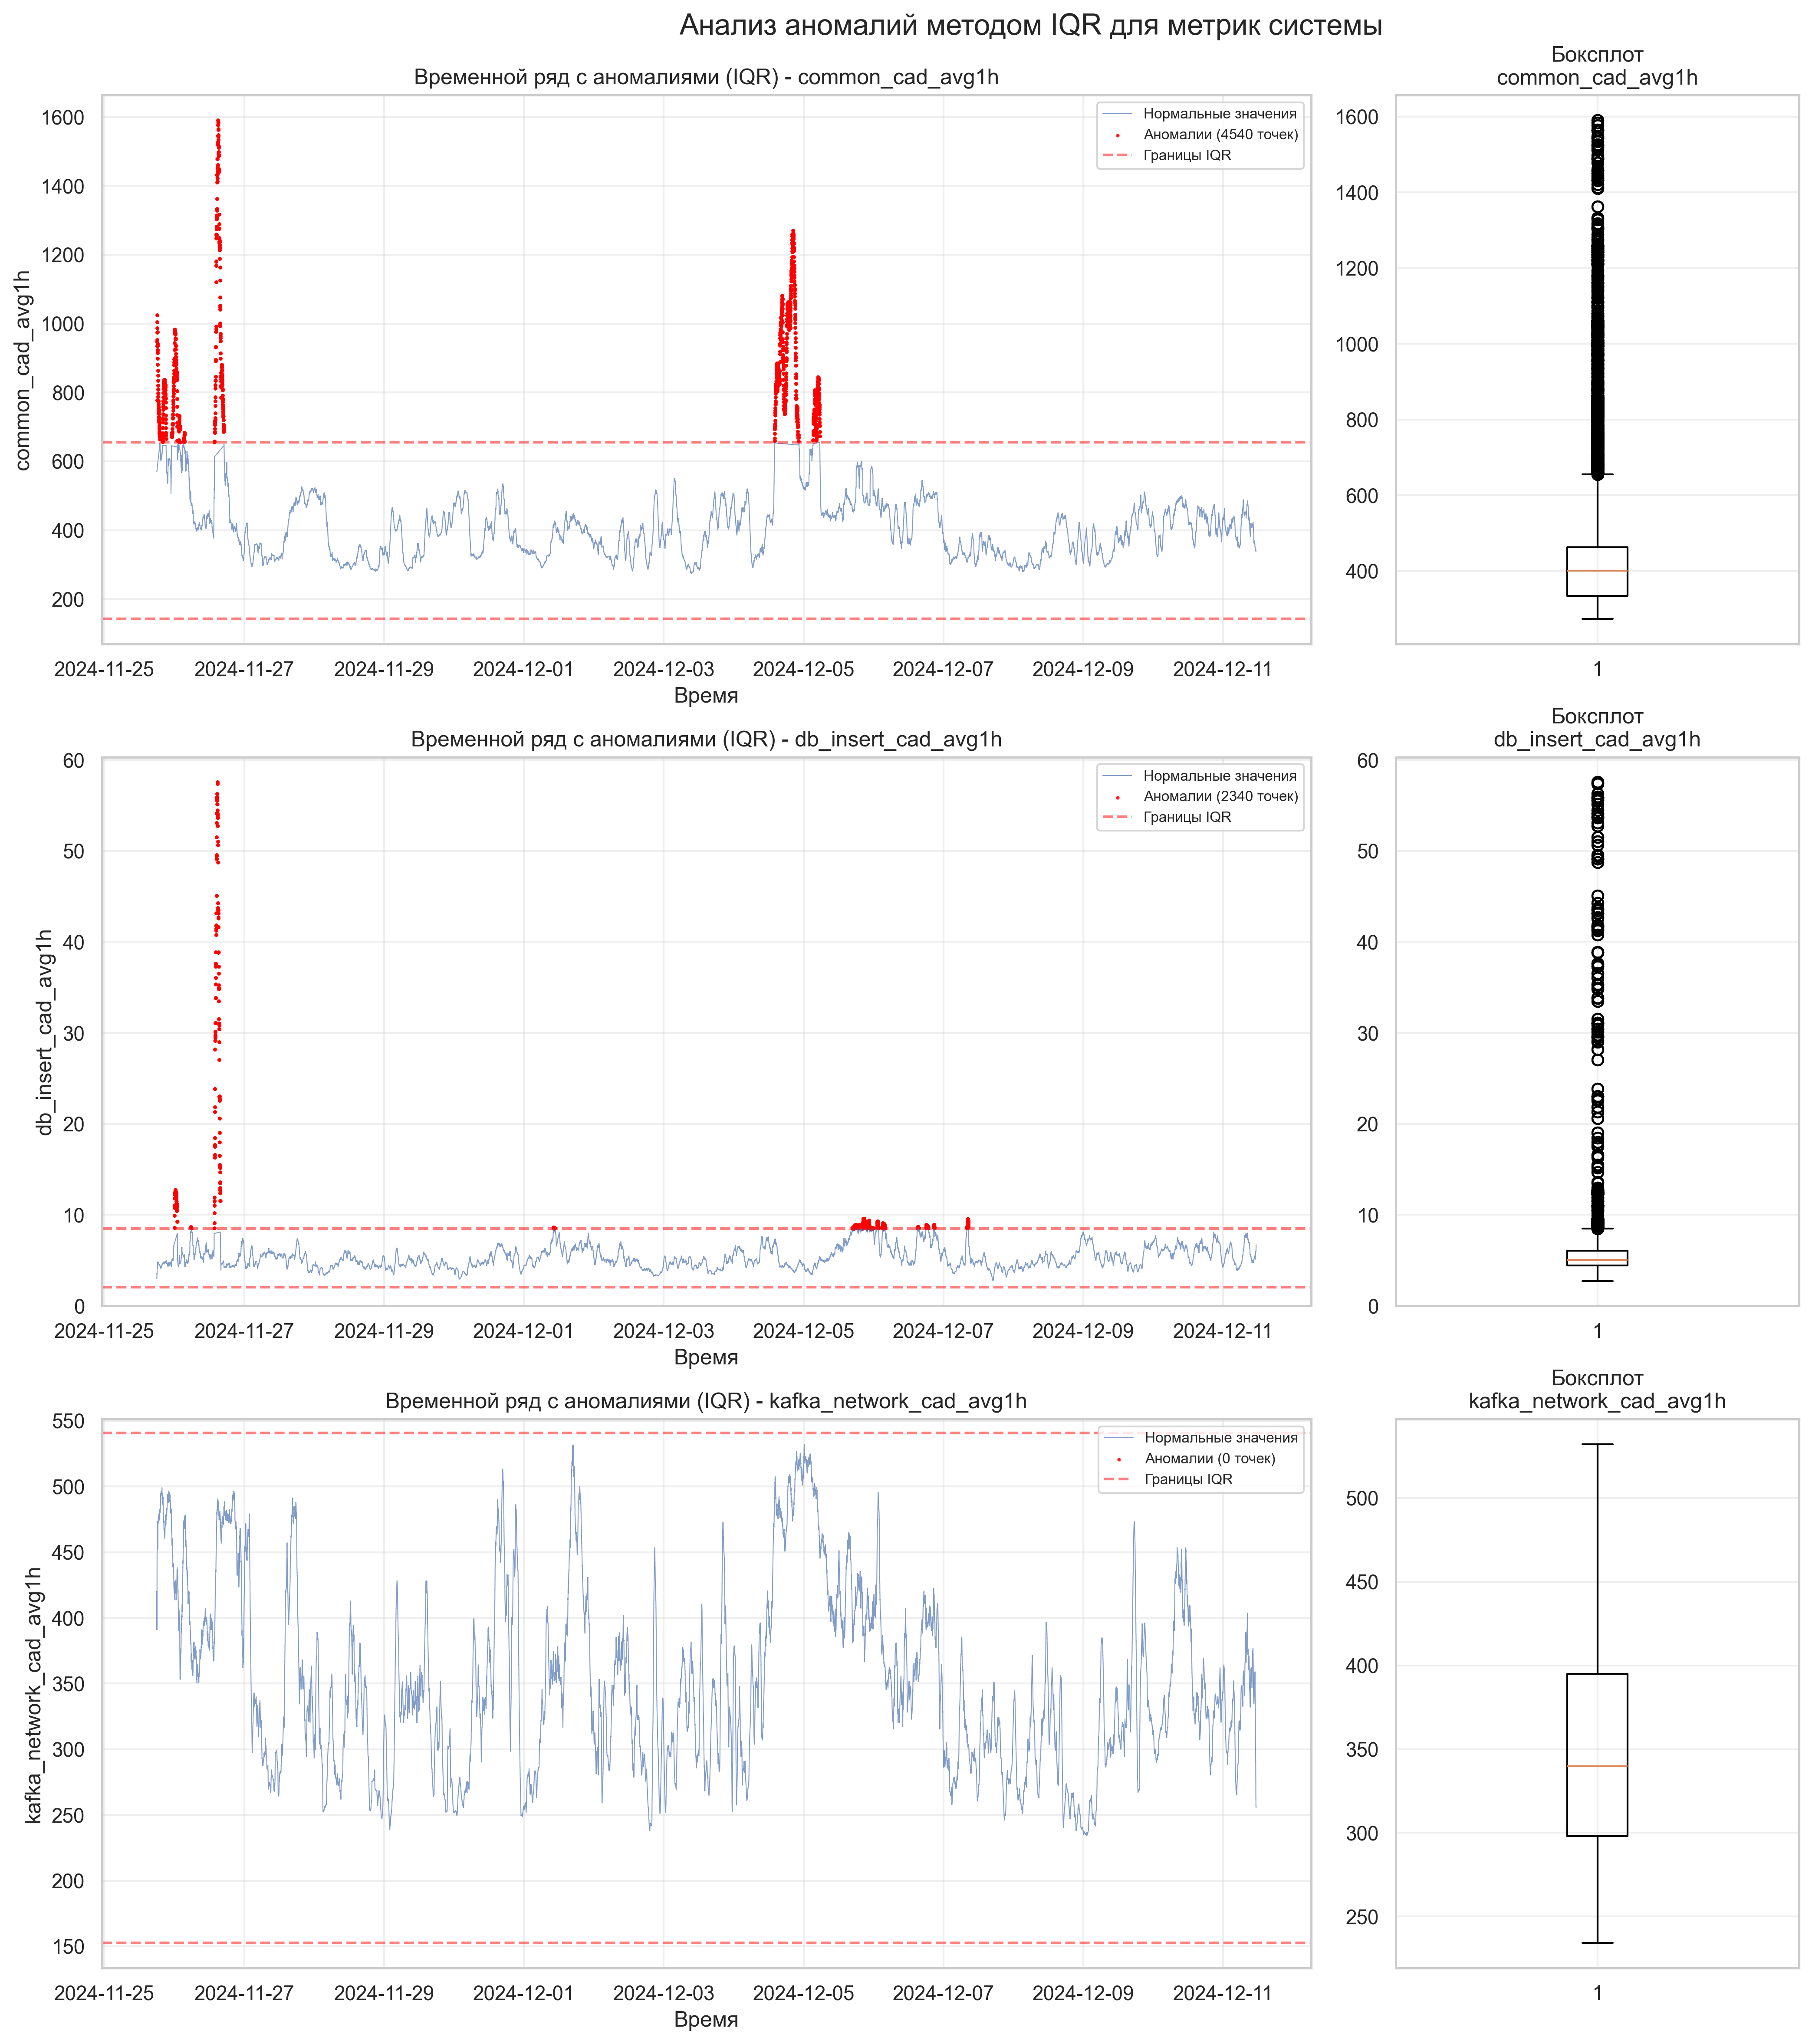

In [15]:
from matplotlib.gridspec import GridSpec

# Анализ выбросов для трех метрик с настроенными пропорциями
metrics = ['common_cad_avg1h', 'db_insert_cad_avg1h', 'kafka_network_cad_avg1h']

plt.figure(figsize=(16, 16))

# Создаем сетку с пропорциями: IQR график занимает 3 части, боксплот 1 часть
gs = GridSpec(3, 4, width_ratios=[3, 1, 0.1, 0.1])  # 3:1 пропорция + небольшие отступы

for idx, metric in enumerate(metrics):
    raw_data = df[metric].dropna()
    
    # Вычисляем границы выбросов
    Q1 = raw_data.quantile(0.25)
    Q3 = raw_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = raw_data[(raw_data < lower_bound) | (raw_data > upper_bound)]
    normal_data = raw_data[(raw_data >= lower_bound) & (raw_data <= upper_bound)]
    
    # 1. Временной ряд с выделением выбросов (IQR plot) - занимает 3/4 ширины
    plt.subplot(gs[idx, 0])
    plt.plot(normal_data.index, normal_data, alpha=0.7, label='Нормальные значения', linewidth=0.5)
    plt.scatter(outliers.index, outliers, color='red', alpha=0.8, s=1, label=f'Аномалии ({len(outliers)} точек)')
    plt.axhline(y=lower_bound, color='red', linestyle='--', alpha=0.5, label=f'Границы IQR')
    plt.axhline(y=upper_bound, color='red', linestyle='--', alpha=0.5)
    plt.title(f'Временной ряд с аномалиями (IQR) - {metric}', fontsize=12)
    plt.xlabel('Время')
    plt.ylabel(metric)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    # 2. Boxplot - занимает 1/4 ширины
    plt.subplot(gs[idx, 1])
    plt.boxplot(raw_data, showfliers=True)
    plt.title(f'Боксплот\n{metric}', fontsize=12)
    plt.ylabel('')
    plt.grid(True, alpha=0.3)
    
    # Выводим статистику
    print(f"{metric}:")
    print(f"  Выбросы: {len(outliers)} ({len(outliers)/len(raw_data)*100:.2f}%)")
    print(f"  Границы: [{lower_bound:.3f}, {upper_bound:.3f}]")
    if len(outliers) > 0:
        print(f"  Мин/Макс выброс: {outliers.min():.3f} / {outliers.max():.3f}")
    print()

plt.suptitle('Анализ аномалий методом IQR для метрик системы', fontsize=16)
plt.tight_layout()
plt.show()

Данные для корреляционного анализа: 90543 точек


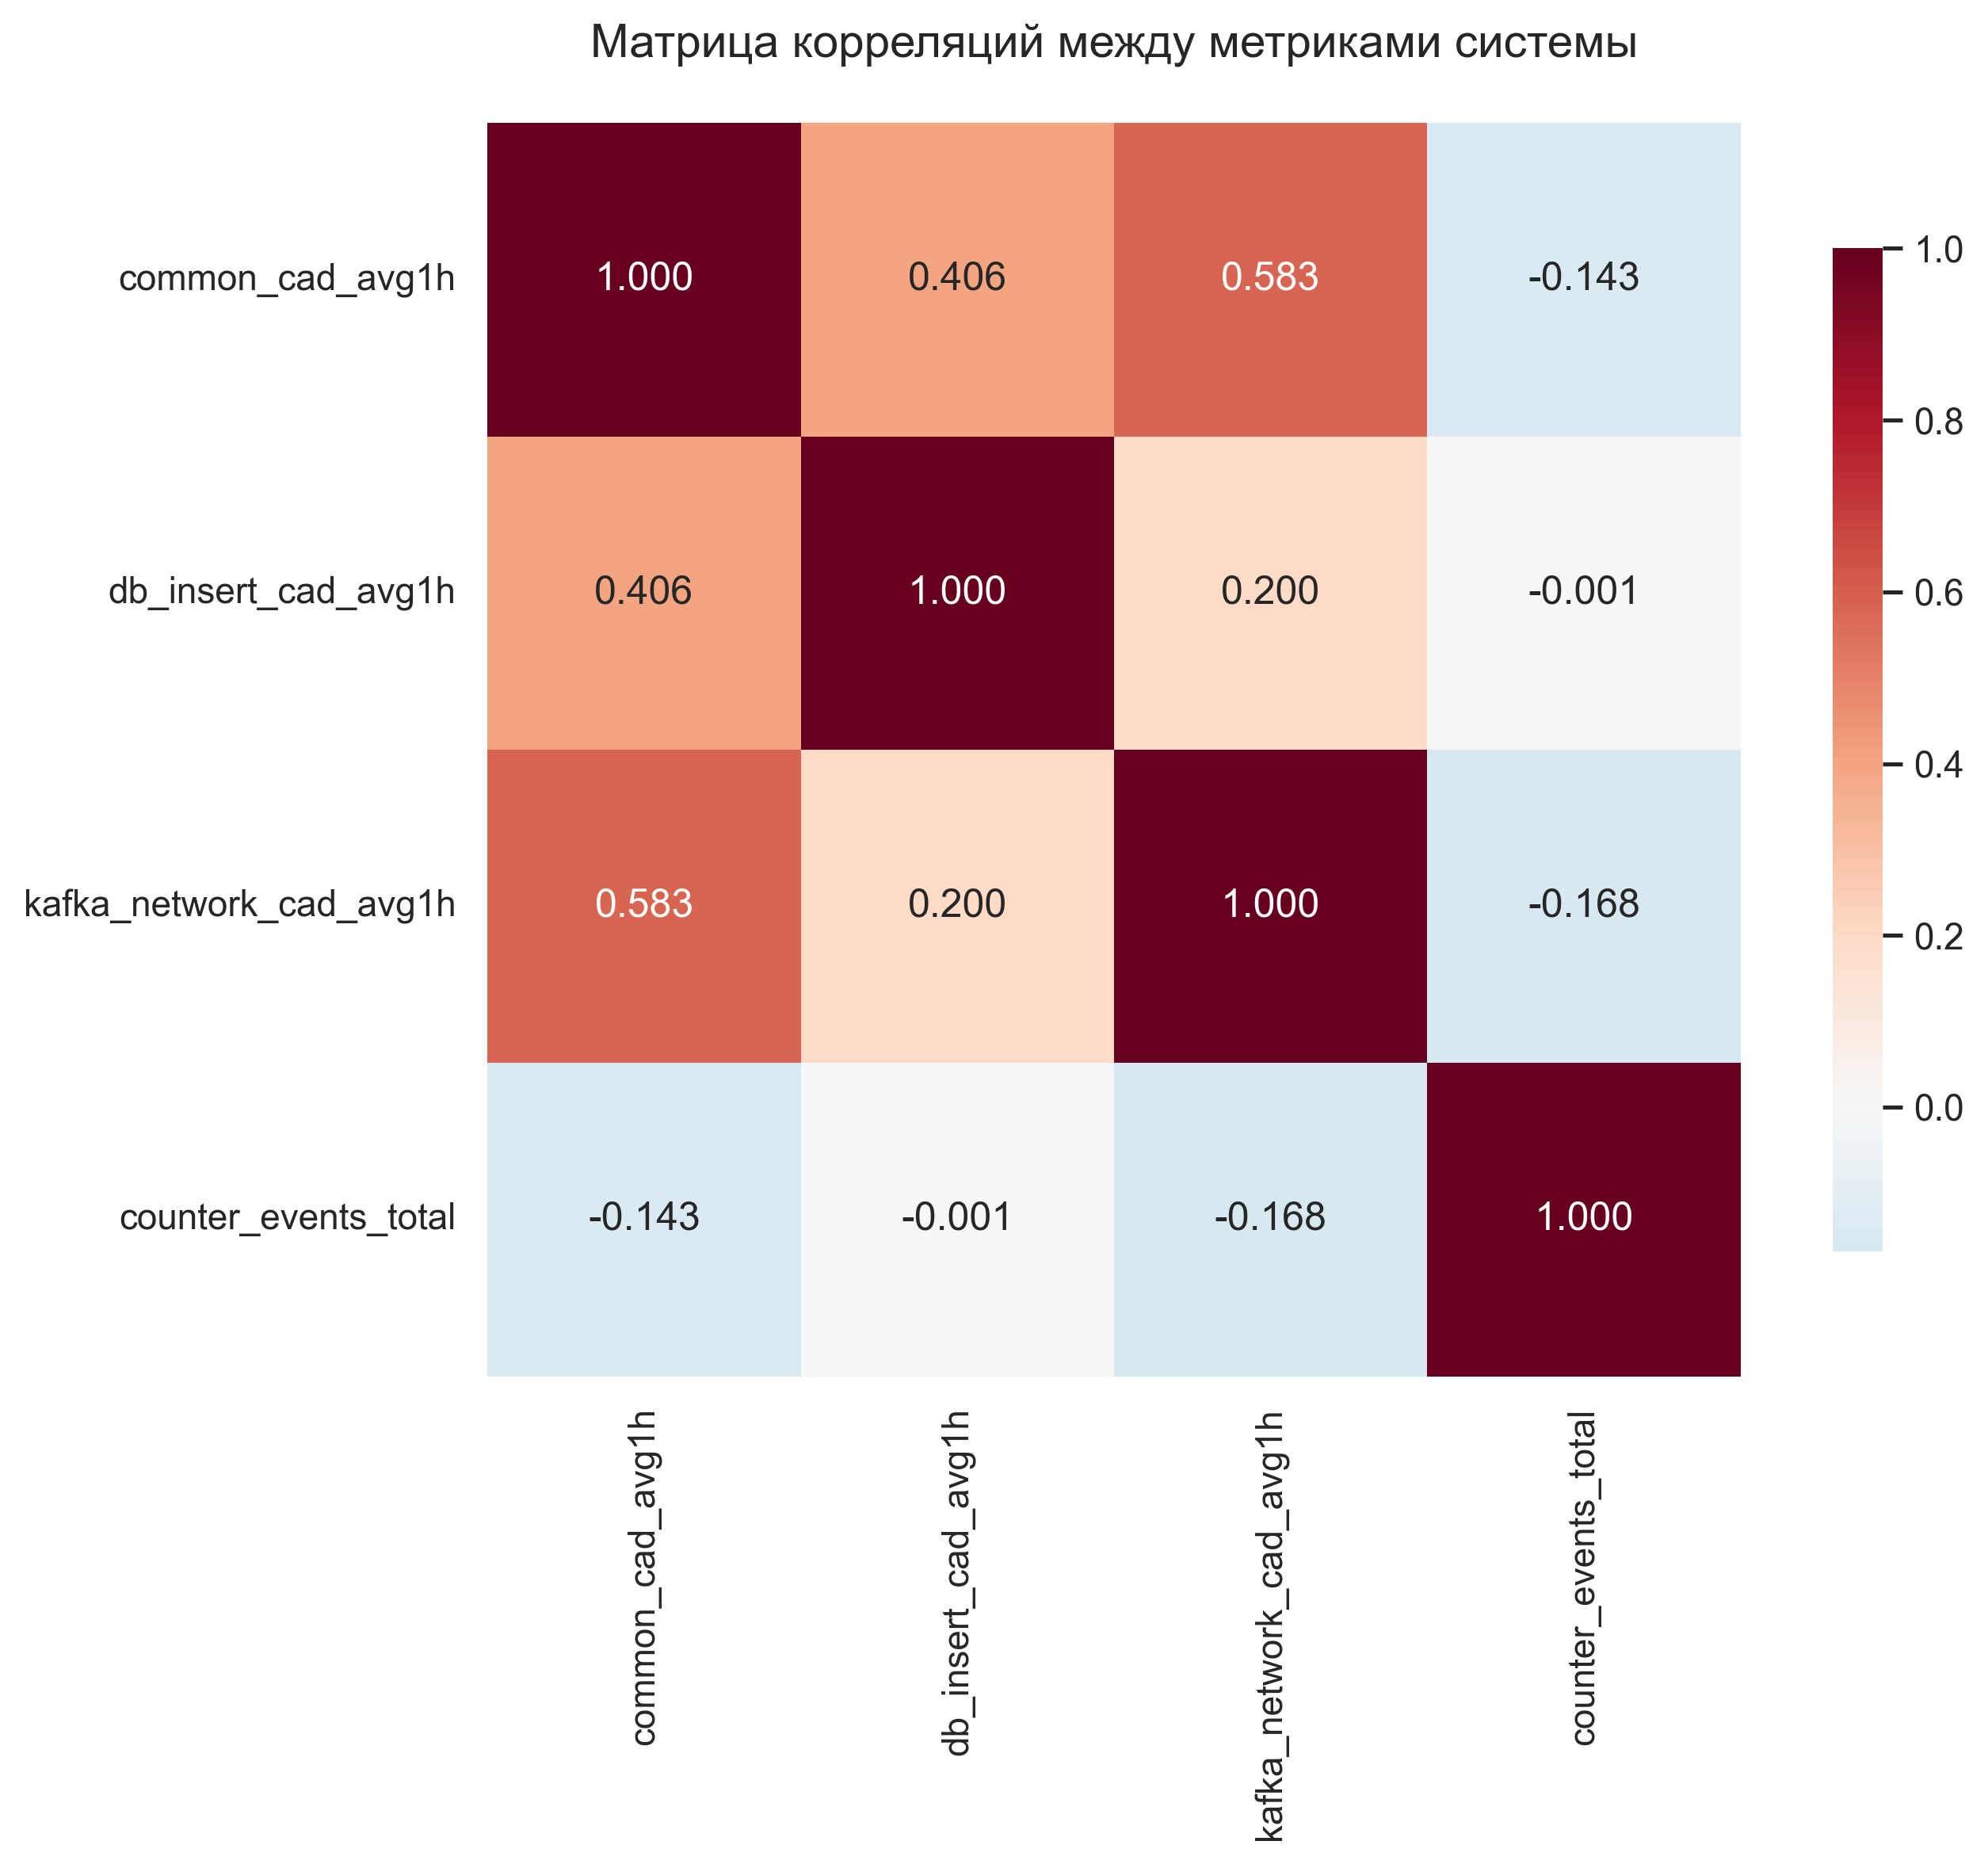

КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ МЕТРИКОЙ (common_cad_avg1h):
  kafka_network_cad_avg1h: 0.583 (умеренная положительная)
  db_insert_cad_avg1h: 0.406 (умеренная положительная)
  counter_events_total: -0.143 (слабая отрицательная)



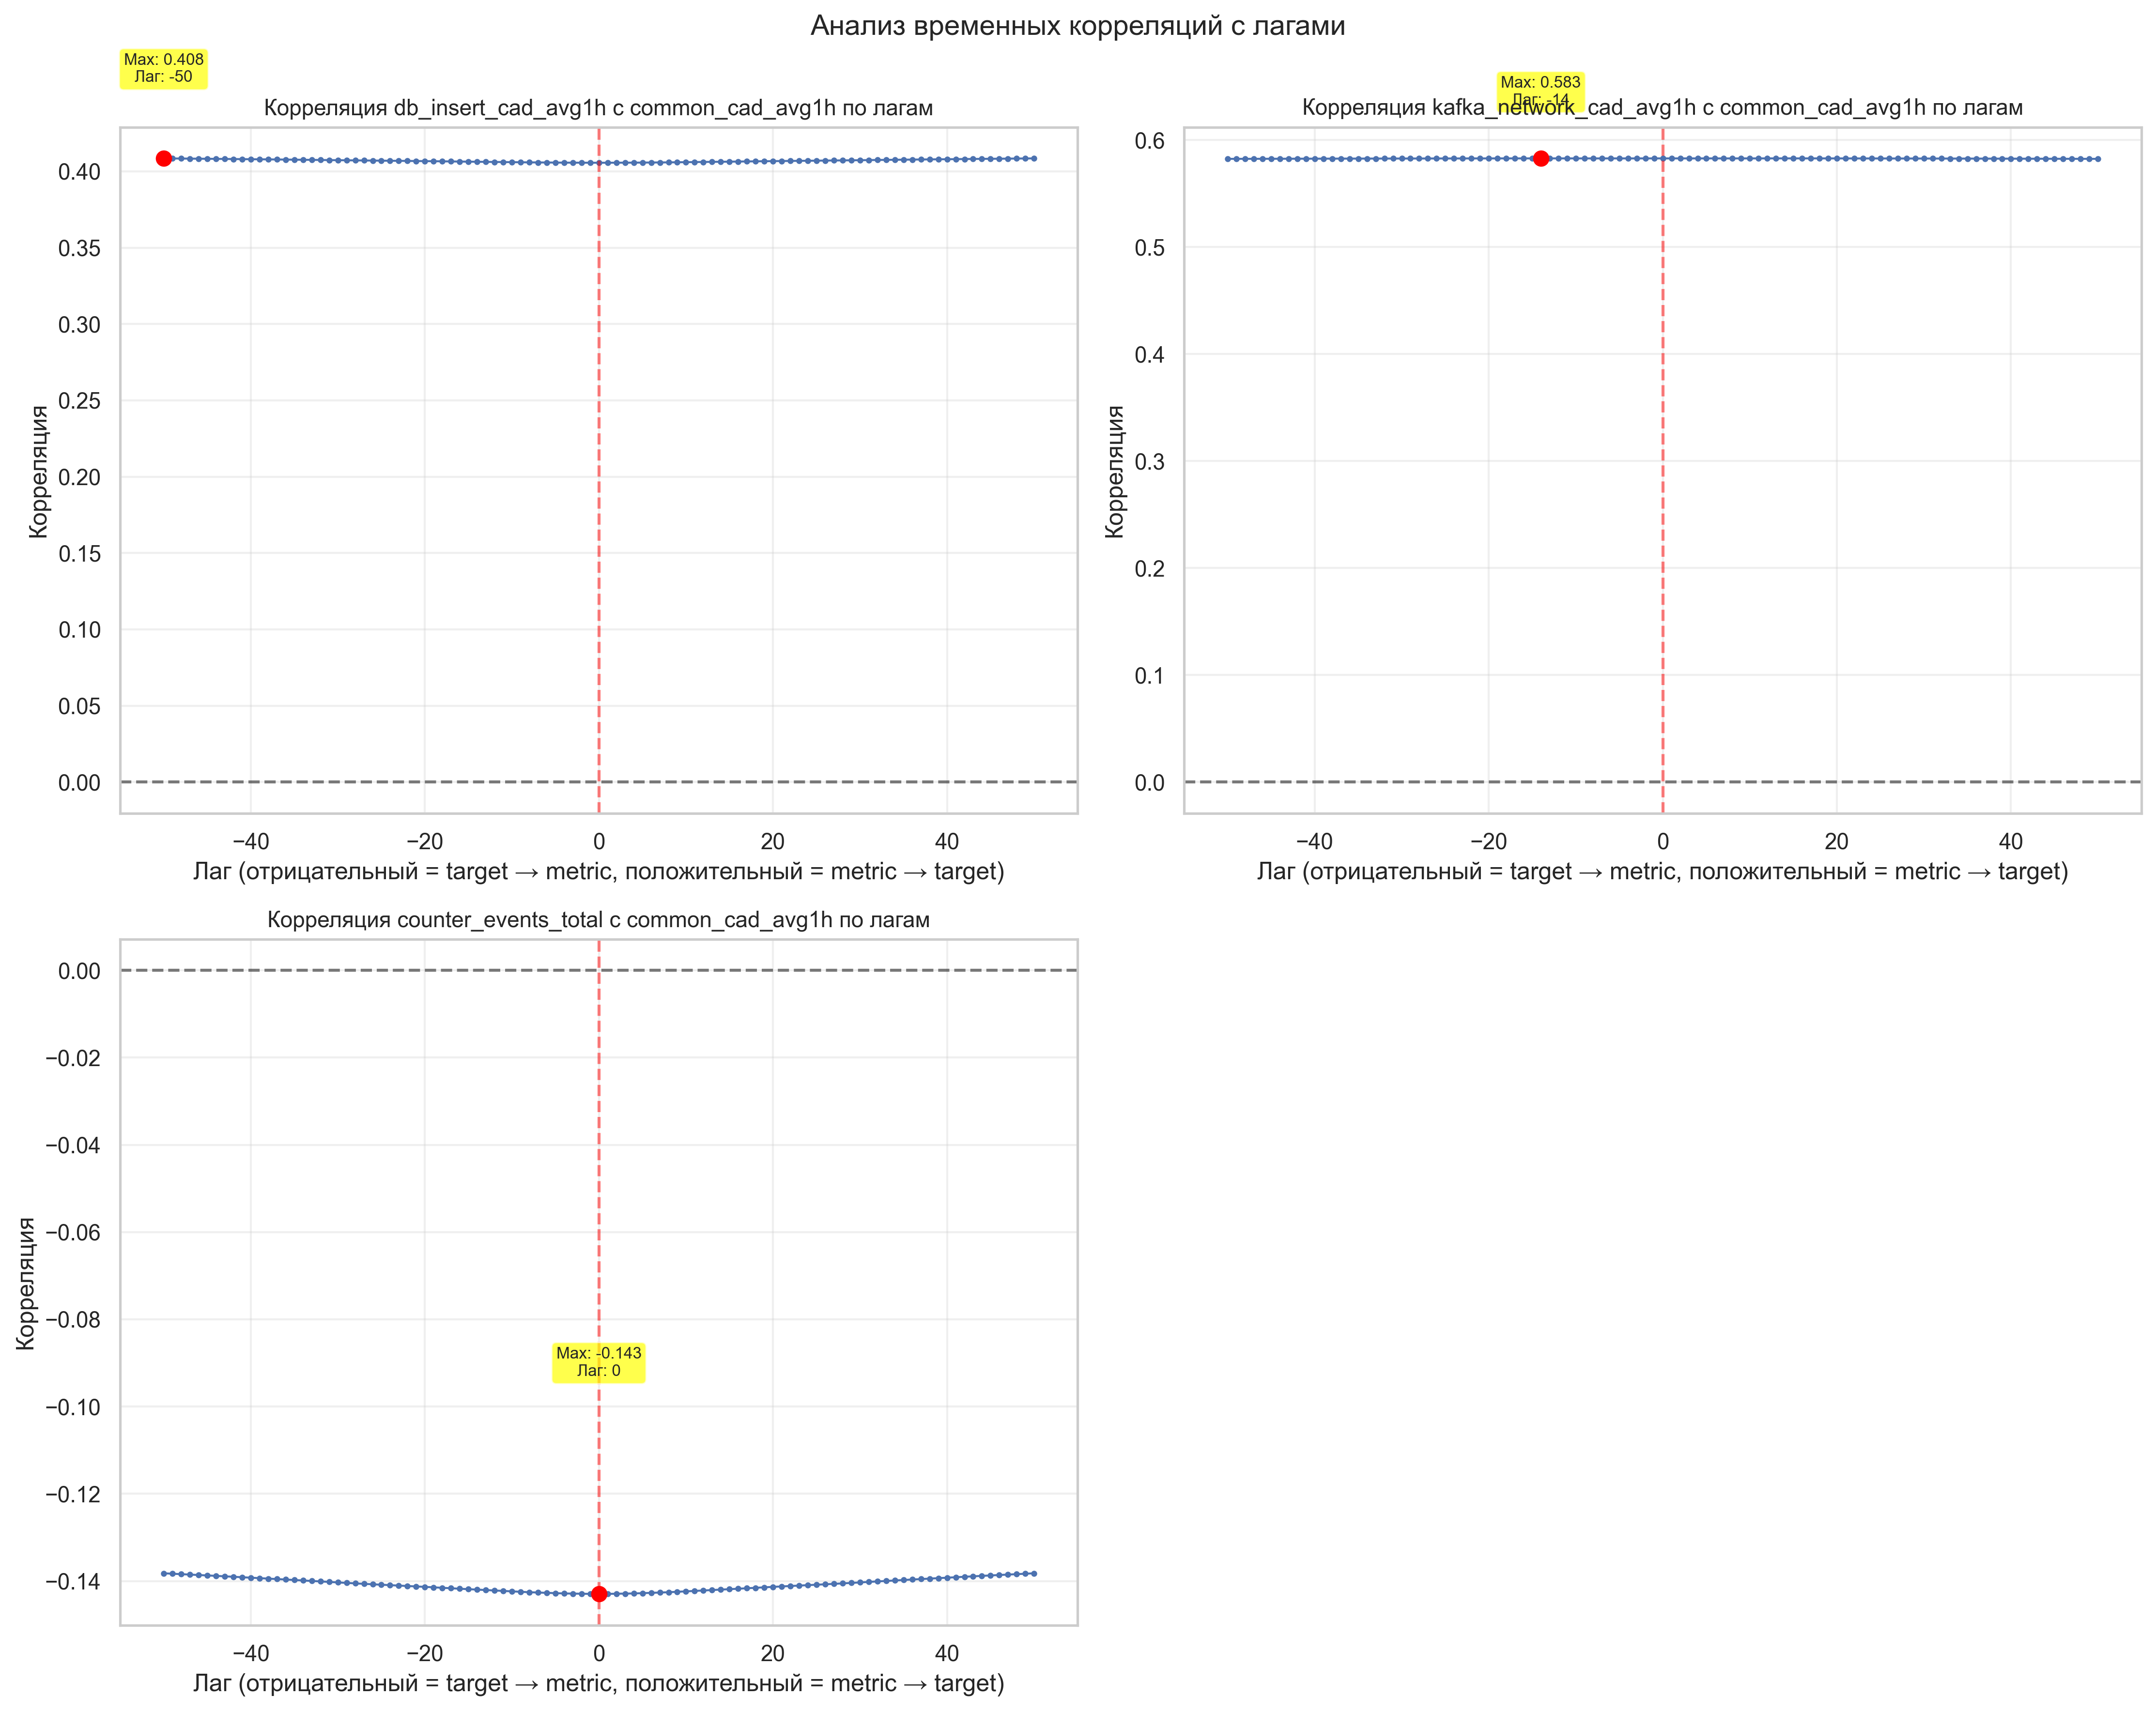

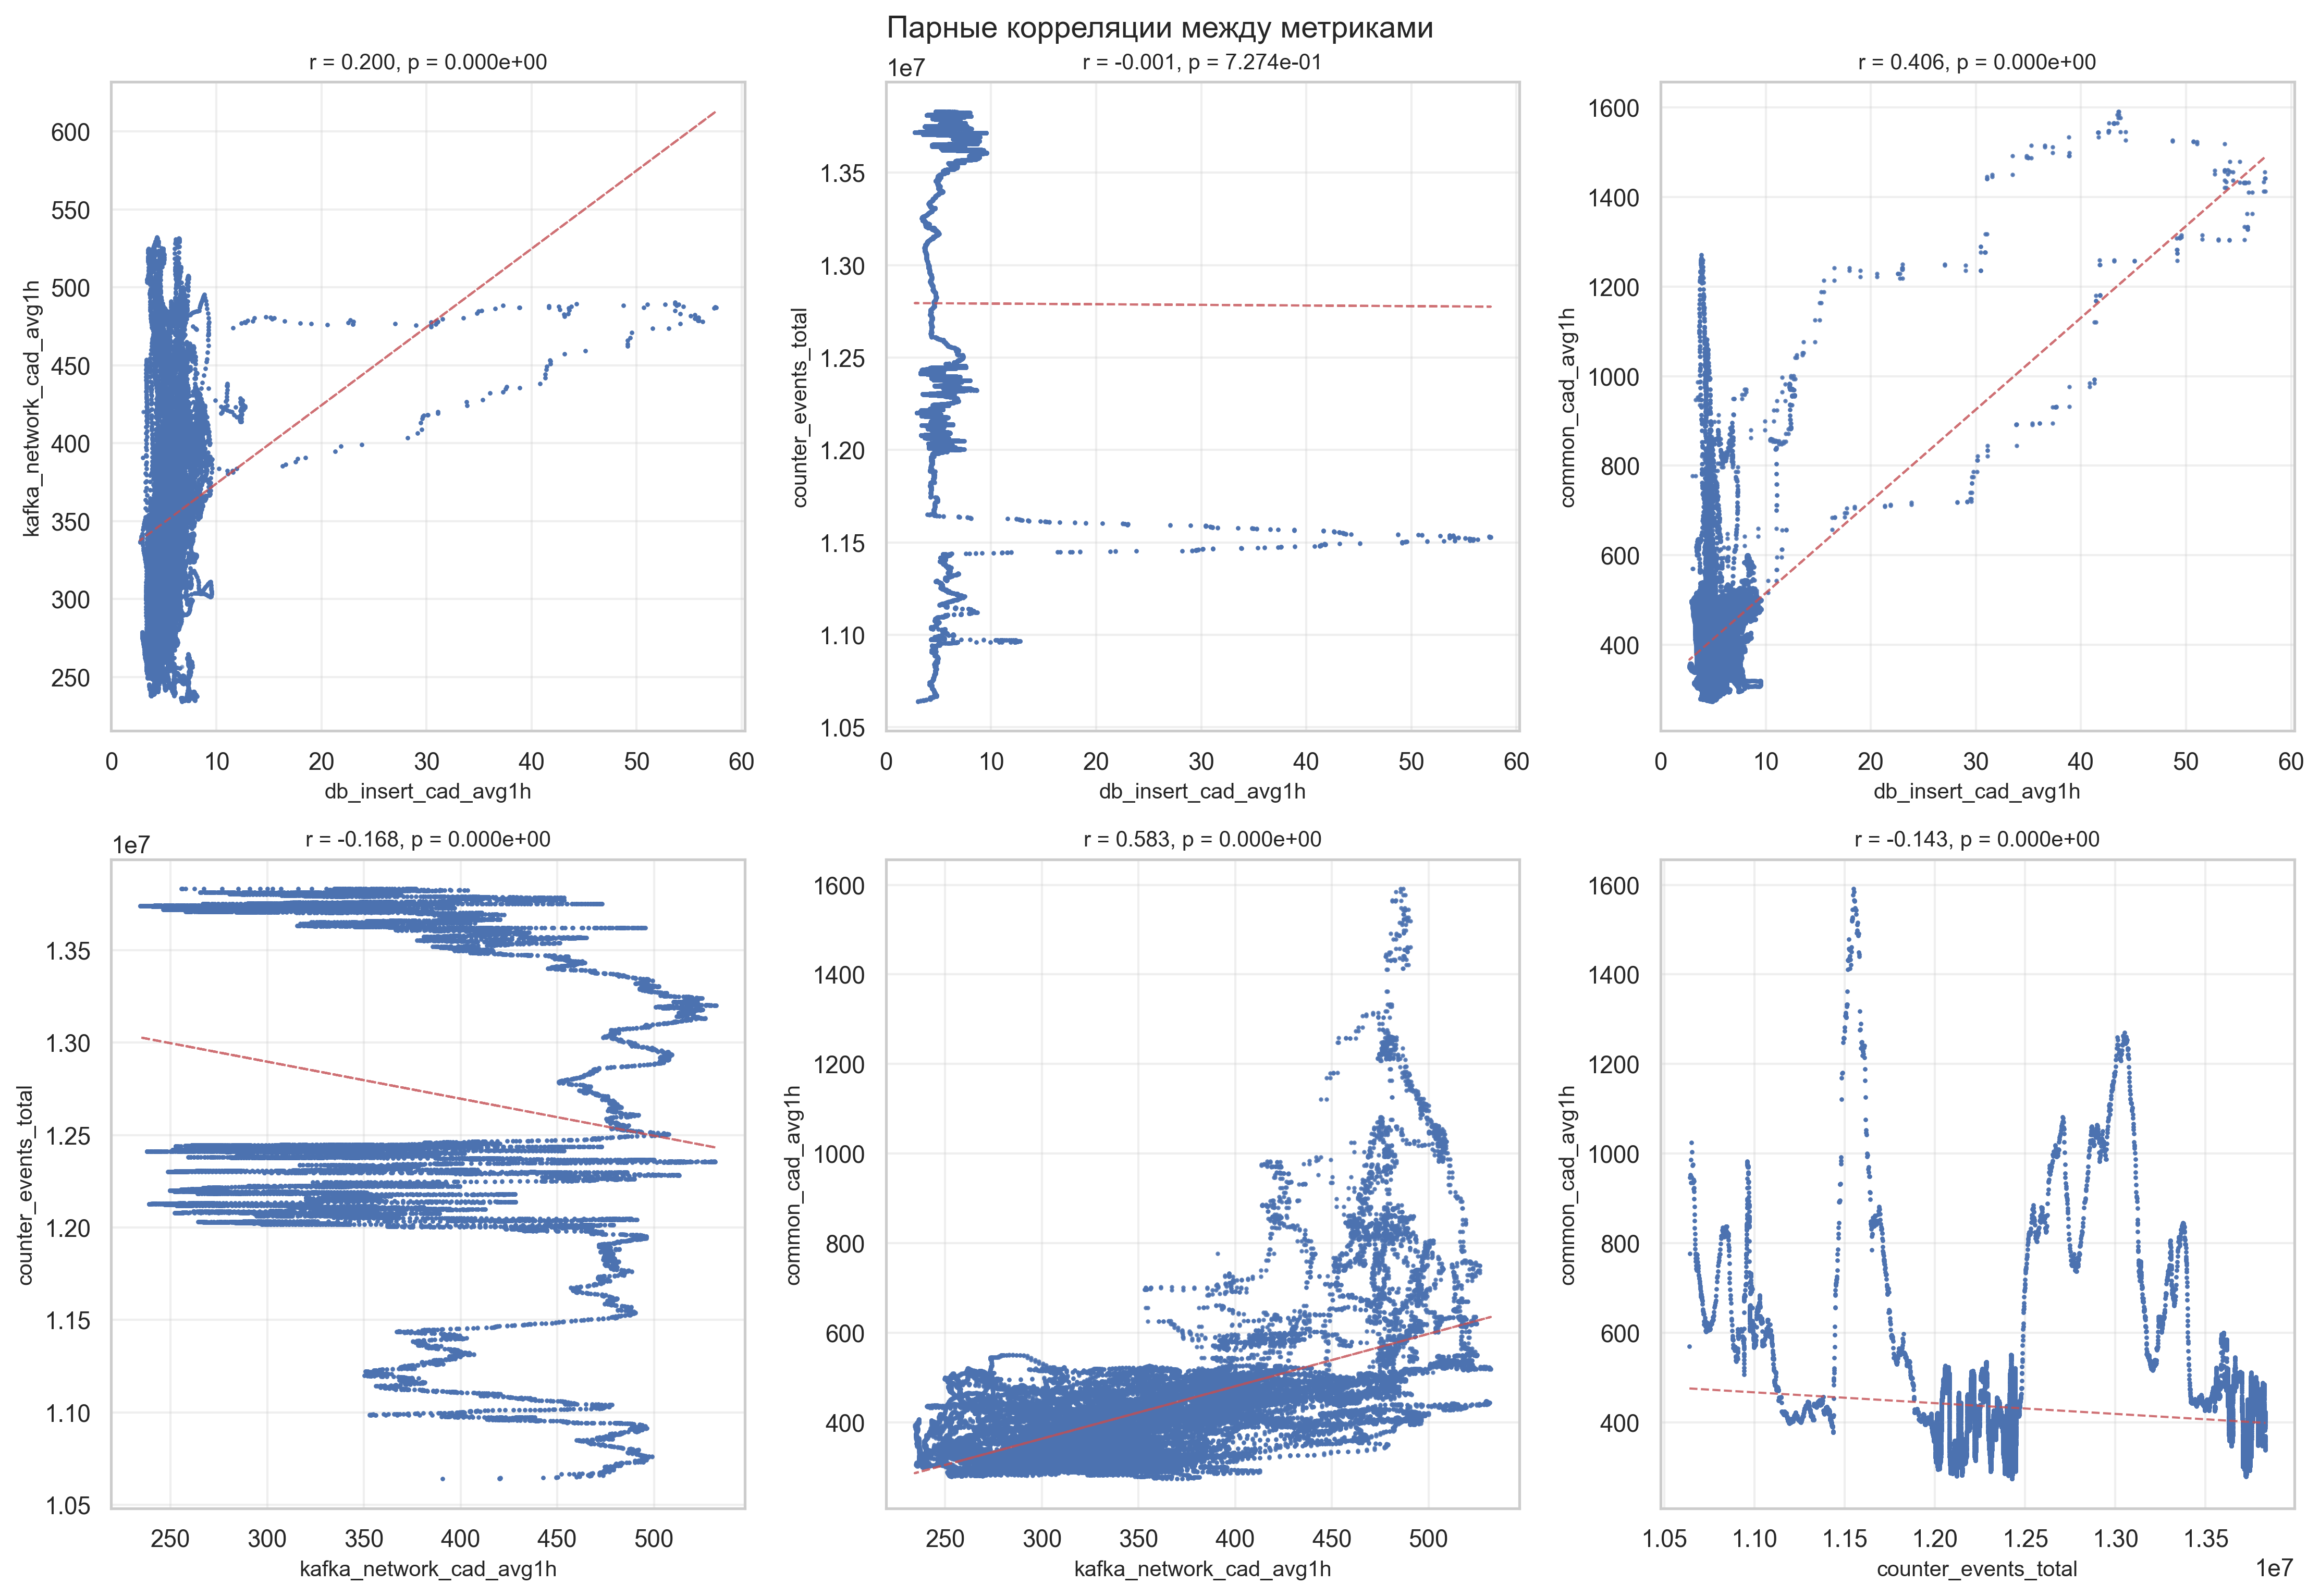

ВЫВОДЫ О НАИБОЛЕЕ ИНФОРМАТИВНЫХ ПРИЗНАКАХ:
1. СТАТИЧЕСКИЕ КОРРЕЛЯЦИИ:
   ✓ kafka_network_cad_avg1h: ВЫСОКАЯ корреляция (0.583)
   ~ db_insert_cad_avg1h: УМЕРЕННАЯ корреляция (0.406)
   ✗ counter_events_total: СЛАБАЯ корреляция (-0.143)

2. ВРЕМЕННЫЕ ВЗАИМОСВЯЗИ (с лагами):
   ✓ db_insert_cad_avg1h: макс. корреляция 0.408 с лагом -50 (db_insert_cad_avg1h следует за common_cad)
   ✓ kafka_network_cad_avg1h: макс. корреляция 0.583 с лагом -14 (kafka_network_cad_avg1h следует за common_cad)
   ✗ counter_events_total: слабые временные взаимосвязи (макс. -0.143)

3. РЕКОМЕНДАЦИИ ДЛЯ ПРОГНОЗИРОВАНИЯ:
   • Использовать как основные признаки: kafka_network_cad_avg1h, db_insert_cad_avg1h
   • Рассмотреть временные лаги для улучшения прогноза
   • Возможно создание комбинированных признаков из коррелирующих метрик


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Подготовка данных для анализа корреляций
metrics = ['common_cad_avg1h', 'db_insert_cad_avg1h', 'kafka_network_cad_avg1h', 'counter_events_total']
correlation_data = df[metrics].dropna()

print(f"Данные для корреляционного анализа: {correlation_data.shape[0]} точек")
print("="*60)

# 1. МАТРИЦА КОРРЕЛЯЦИЙ - ТЕПЛОВАЯ КАРТА
plt.figure(figsize=(10, 8))
correlation_matrix = correlation_data.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": .8},
            annot_kws={'size': 12})

plt.title('Матрица корреляций между метриками системы', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Анализ корреляций с целевой метрикой
target_correlations = correlation_matrix['common_cad_avg1h'].drop('common_cad_avg1h').sort_values(key=abs, ascending=False)
print("КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ МЕТРИКОЙ (common_cad_avg1h):")
for metric, corr in target_correlations.items():
    strength = "сильная" if abs(corr) > 0.7 else "умеренная" if abs(corr) > 0.3 else "слабая"
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"  {metric}: {corr:.3f} ({strength} {direction})")
print()

# 2. ВРЕМЕННЫЕ КОРРЕЛЯЦИИ С ЛАГАМИ
max_lag = 50  # максимальный лаг для анализа
target_metric = 'common_cad_avg1h'
other_metrics = [m for m in metrics if m != target_metric]

plt.figure(figsize=(15, 12))

lag_results = {}
for idx, metric in enumerate(other_metrics):
    lags = range(-max_lag, max_lag + 1)
    correlations = []
    
    for lag in lags:
        if lag == 0:
            corr = correlation_data[target_metric].corr(correlation_data[metric])
        elif lag > 0:
            # Положительный лаг: metric влияет на target с задержкой lag
            corr = correlation_data[target_metric].iloc[lag:].corr(correlation_data[metric].iloc[:-lag])
        else:
            # Отрицательный лаг: target влияет на metric с задержкой |lag|
            corr = correlation_data[target_metric].iloc[:lag].corr(correlation_data[metric].iloc[-lag:])
        
        correlations.append(corr if not np.isnan(corr) else 0)
    
    lag_results[metric] = correlations
    
    plt.subplot(2, 2, idx + 1)
    plt.plot(lags, correlations, marker='o', markersize=2, linewidth=1)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    plt.title(f'Корреляция {metric} с {target_metric} по лагам', fontsize=11)
    plt.xlabel('Лаг (отрицательный = target → metric, положительный = metric → target)')
    plt.ylabel('Корреляция')
    plt.grid(True, alpha=0.3)
    
    # Находим максимальные корреляции
    max_corr = max(correlations, key=abs)
    max_lag_idx = correlations.index(max_corr)
    max_lag_value = lags[max_lag_idx]
    plt.scatter([max_lag_value], [max_corr], color='red', s=50, zorder=5)
    plt.text(max_lag_value, max_corr + 0.05, f'Max: {max_corr:.3f}\nЛаг: {max_lag_value}', 
             ha='center', fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.suptitle('Анализ временных корреляций с лагами', fontsize=14)
plt.tight_layout()
plt.savefig('lag_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. ПАРНЫЕ SCATTER PLOTS
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

plot_idx = 0
for i, metric1 in enumerate(other_metrics + [target_metric]):
    for j, metric2 in enumerate(other_metrics + [target_metric]):
        if i < j:  # Только уникальные пары
            ax = axes[plot_idx]
            
            x_data = correlation_data[metric1]
            y_data = correlation_data[metric2]
            
            ax.scatter(x_data, y_data, alpha=0.6, s=1)
            
            # Добавляем линию тренда
            z = np.polyfit(x_data, y_data, 1)
            p = np.poly1d(z)
            ax.plot(x_data, p(x_data), "r--", alpha=0.8, linewidth=1)
            
            # Вычисляем корреляцию
            corr, p_value = pearsonr(x_data, y_data)
            
            ax.set_xlabel(metric1, fontsize=10)
            ax.set_ylabel(metric2, fontsize=10)
            ax.set_title(f'r = {corr:.3f}, p = {p_value:.3e}', fontsize=10)
            ax.grid(True, alpha=0.3)
            
            plot_idx += 1

# Скрываем лишние subplot'ы
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Парные корреляции между метриками', fontsize=14)
plt.tight_layout()
plt.savefig('pairwise_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# ВЫВОДЫ И РЕКОМЕНДАЦИИ
print("="*60)
print("ВЫВОДЫ О НАИБОЛЕЕ ИНФОРМАТИВНЫХ ПРИЗНАКАХ:")
print("="*60)

# Анализ корреляций
print("1. СТАТИЧЕСКИЕ КОРРЕЛЯЦИИ:")
for metric, corr in target_correlations.items():
    if abs(corr) > 0.5:
        print(f"   ✓ {metric}: ВЫСОКАЯ корреляция ({corr:.3f})")
    elif abs(corr) > 0.3:
        print(f"   ~ {metric}: УМЕРЕННАЯ корреляция ({corr:.3f})")
    else:
        print(f"   ✗ {metric}: СЛАБАЯ корреляция ({corr:.3f})")

print("\n2. ВРЕМЕННЫЕ ВЗАИМОСВЯЗИ (с лагами):")
for metric in other_metrics:
    correlations = lag_results[metric]
    max_corr = max(correlations, key=abs)
    max_lag_idx = correlations.index(max_corr)
    max_lag_value = list(range(-max_lag, max_lag + 1))[max_lag_idx]
    
    if abs(max_corr) > 0.3:
        direction = "предшествует" if max_lag_value > 0 else "следует за"
        print(f"   ✓ {metric}: макс. корреляция {max_corr:.3f} с лагом {max_lag_value} ({metric} {direction} common_cad)")
    else:
        print(f"   ✗ {metric}: слабые временные взаимосвязи (макс. {max_corr:.3f})")

print("\n3. РЕКОМЕНДАЦИИ ДЛЯ ПРОГНОЗИРОВАНИЯ:")
informative_features = [metric for metric, corr in target_correlations.items() if abs(corr) > 0.3]
if informative_features:
    print(f"   • Использовать как основные признаки: {', '.join(informative_features)}")
else:
    print("   • Все признаки показывают слабую корреляцию с целевой метрикой")

print(f"   • Рассмотреть временные лаги для улучшения прогноза")
print(f"   • Возможно создание комбинированных признаков из коррелирующих метрик")

In [17]:
# Анализ стационарности временного ряда
from statsmodels.tsa.stattools import adfuller, kpss

print("=== Тесты на стационарность ===")

# Тест Дики-Фуллера (ADF)
adf_result = adfuller(raw_data.dropna())
print("Расширенный тест Дики-Фуллера (ADF):")
print(f"ADF статистика: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Критические значения:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value:.3f}")
print(f"Ряд {'стационарен' if adf_result[1] < 0.05 else 'НЕ стационарен'} (α=0.05)")

print("\n" + "="*50)

# Тест KPSS
kpss_result = kpss(raw_data.dropna(), regression='c')
print("Тест KPSS:")
print(f"KPSS статистика: {kpss_result[0]:.6f}")
print(f"p-value: {kpss_result[1]:.6f}")
print("Критические значения:")
for key, value in kpss_result[3].items():
    print(f"\t{key}: {value:.3f}")
print(f"Ряд {'стационарен' if kpss_result[1] > 0.05 else 'НЕ стационарен'} (α=0.05)")

print("\n" + "="*50)
print("Интерпретация:")
if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
    print("✅ Ряд СТАЦИОНАРЕН по обоим тестам")
elif adf_result[1] >= 0.05 and kpss_result[1] <= 0.05:
    print("❌ Ряд НЕ СТАЦИОНАРЕН по обоим тестам")
else:
    print("⚠️  Противоречивые результаты тестов - требуется дополнительный анализ")


=== Тесты на стационарность ===
Расширенный тест Дики-Фуллера (ADF):
ADF статистика: -7.022692
p-value: 0.000000
Критические значения:
	1%: -3.430
	5%: -2.862
	10%: -2.567
Ряд стационарен (α=0.05)

Тест KPSS:
KPSS статистика: 2.380168
p-value: 0.010000
Критические значения:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Ряд НЕ стационарен (α=0.05)

Интерпретация:
⚠️  Противоречивые результаты тестов - требуется дополнительный анализ


/var/folders/hz/g0q481y17153sdyxw9_71p380000gn/T/ipykernel_97506/3262242277.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(raw_data.dropna(), regression='c')


In [ ]:
import numpy as np

df_diff = df['common_cad_avg1h'].diff().dropna()
df_diff[-1000:].plot(figsize=(10, 5))

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df_diff)

In [ ]:
from statsmodels.tsa.stattools import adfuller

print(adfuller(df_diff))